In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pearsonr, mannwhitneyu
from sklearn.metrics import precision_recall_curve, roc_curve
plt.rcParams['font.family'] = 'Malgun Gothic'  
plt.rcParams['axes.unicode_minus'] = False     

In [2]:
df = pd.read_csv('course_final.csv')

In [3]:
funnel = {
    "registered": len(df),
    "viewed": df["viewed"].sum(),
    "explored": df["explored"].sum(),
}

funnel_df = pd.DataFrame.from_dict(funnel, orient="index", columns=["count"])
funnel_df["conversion_rate"] = funnel_df["count"] / funnel_df.iloc[0,0]

print(funnel_df)

             count  conversion_rate
registered  533993         1.000000
viewed      325361         0.609298
explored     37584         0.070383


In [4]:
df["drop_view"] = (df["viewed"] == 0)
df["drop_explore"] = (df["viewed"] == 1) & (df["explored"] == 0)

print(df[["drop_view", "drop_explore",]].mean())

drop_view       0.390702
drop_explore    0.538915
dtype: float64


변수들에 대한 기본 분포 확인

In [5]:
# 분석 대상 변수
funnel_cols = ["viewed", "explored"]
behavior_cols = ["nchapters", "nplay_video", "nevents", "ndays_act", "nforum_posts"]
demo_cat_cols = ["age_group", "LoE_DI", "gender"]

In [6]:
# age는 연속형 demographic
demo_cont_cols = ["age"]

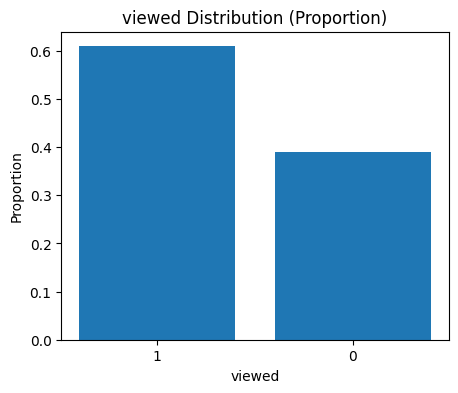

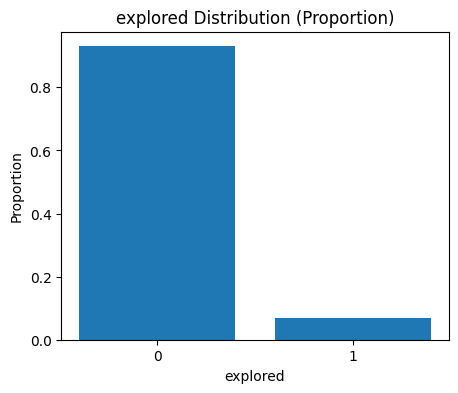

In [7]:

funnel_cols = ["viewed", "explored"]

for col in funnel_cols:
    counts = df[col].value_counts(normalize=True)

    plt.figure(figsize=(5,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"{col} Distribution (Proportion)")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.grid(False)
    plt.show()

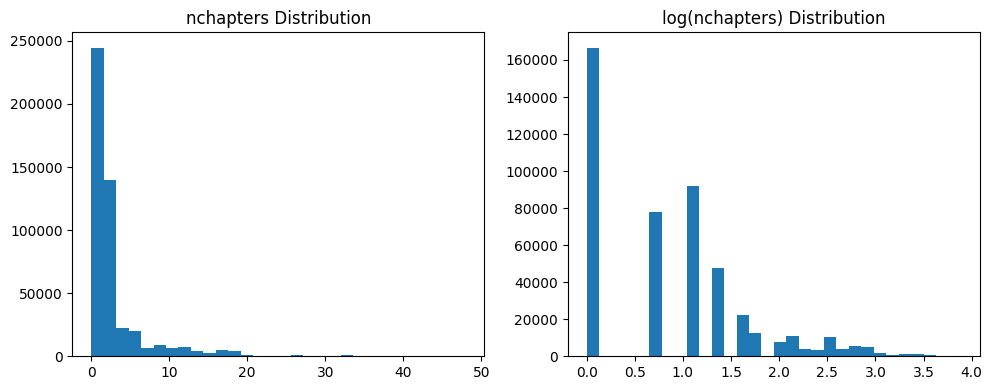

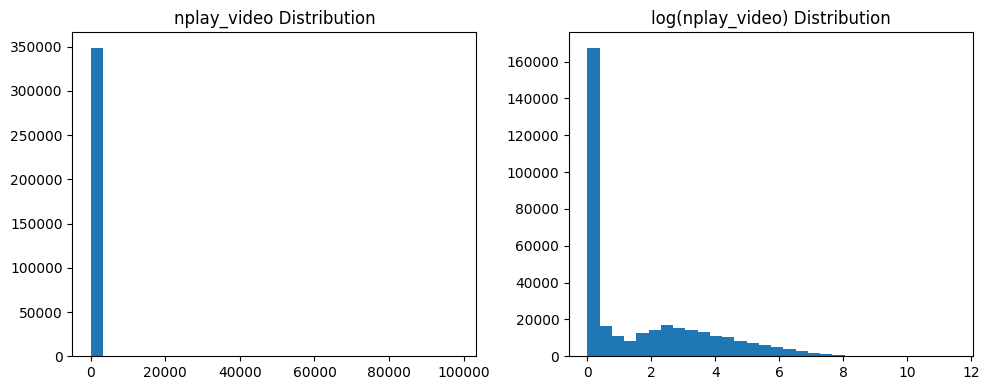

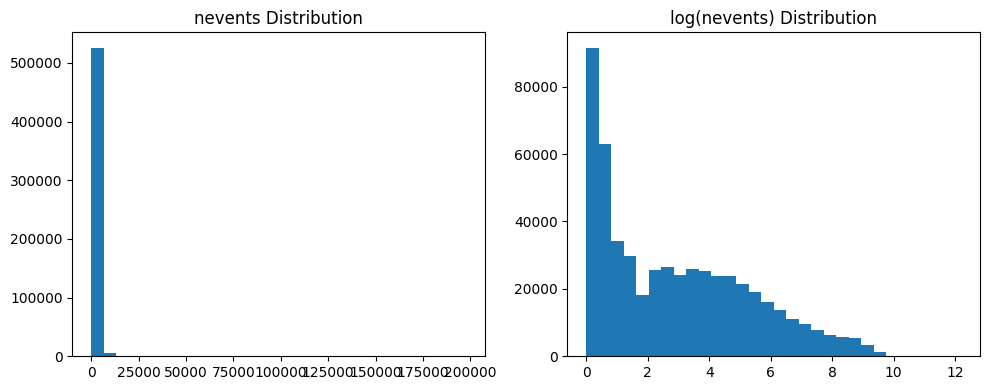

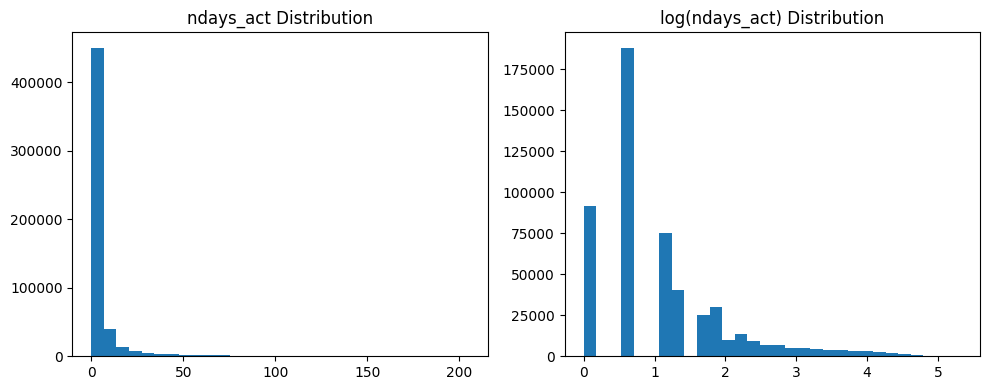

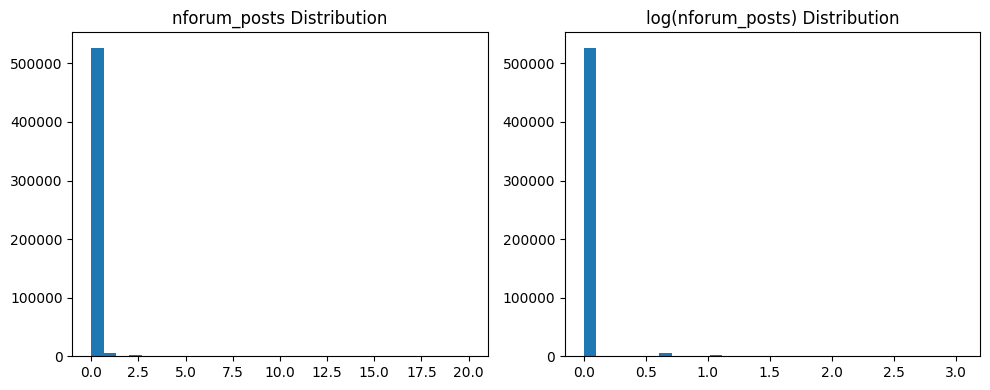

In [8]:
for col in behavior_cols:
    plt.figure(figsize=(10,4))

    # 원본
    plt.subplot(1,2,1)
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"{col} Distribution")

    # 로그 변환
    plt.subplot(1,2,2)
    plt.hist(np.log1p(df[col].dropna()), bins=30)
    plt.title(f"log({col}) Distribution")

    plt.tight_layout()
    plt.show()

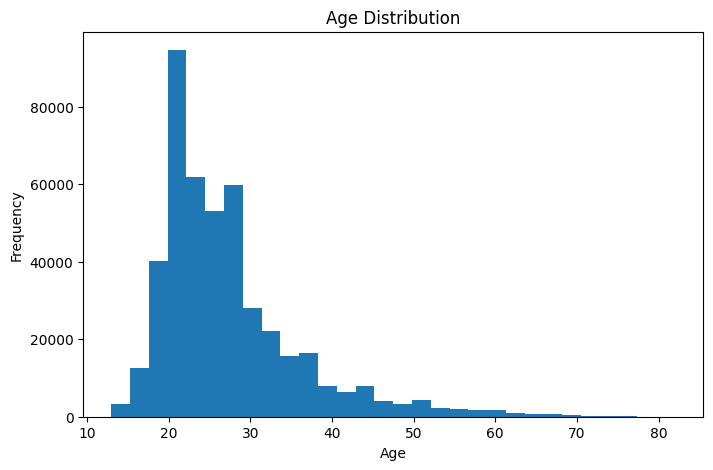

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(False)
plt.show()

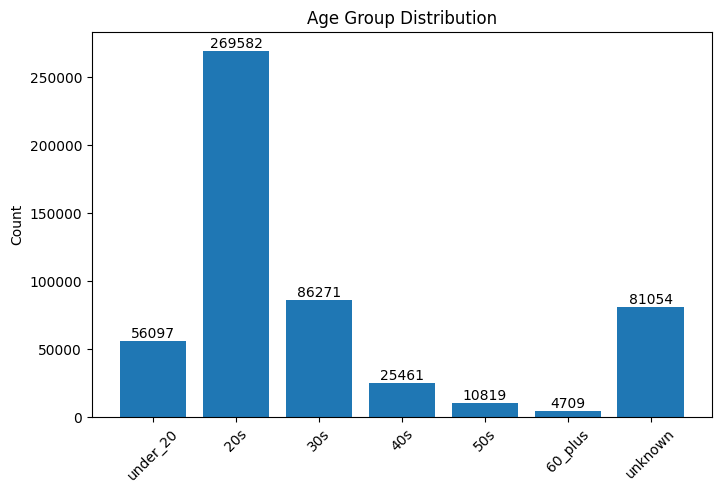

In [10]:
order = ["under_20", "20s", "30s", "40s", "50s", "60_plus", "unknown"]

age_counts = (
    df["age_group"]
    .value_counts()
    .reindex(order)
)

plt.figure(figsize=(8,5))
plt.bar(age_counts.index.astype(str), age_counts.values)
plt.title("Age Group Distribution")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.grid(False)

for i, v in enumerate(age_counts.values):
    if not pd.isna(v):
        plt.text(i, v, str(int(v)), ha='center', va='bottom')
plt.show()

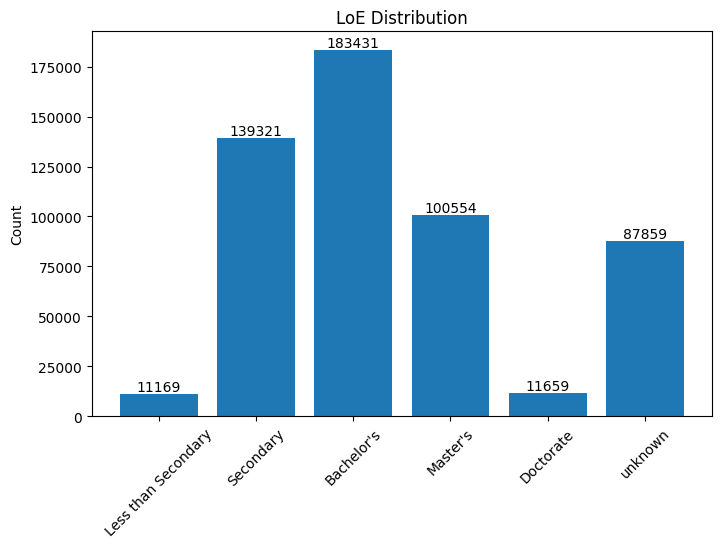

In [11]:
order = [
    "Less than Secondary",
    "Secondary",
    "Bachelor's",
    "Master's",
    "Doctorate",
    "unknown"
]

loe_counts = (
    df["LoE_DI"]
    .value_counts()
    .reindex(order)
)

plt.figure(figsize=(8,5))
plt.bar(loe_counts.index.astype(str), loe_counts.values)

plt.title("LoE Distribution")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.grid(False)

for i, v in enumerate(loe_counts.values):
    if not pd.isna(v):
        plt.text(i, v, str(int(v)), ha='center', va='bottom')

plt.show()

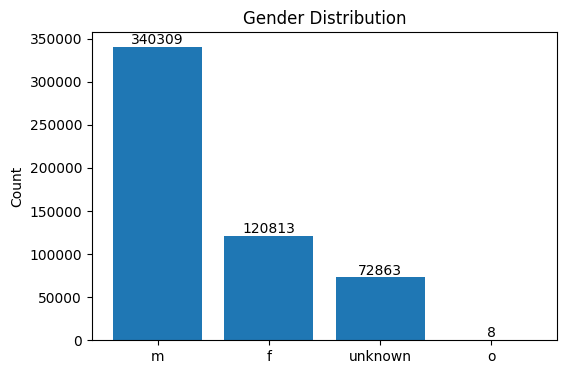

In [12]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender_counts.index.astype(str), gender_counts.values)
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.grid(False)

for i, v in enumerate(gender_counts.values):
    if not pd.isna(v):
        plt.text(i, v, str(int(v)), ha='center', va='bottom')

plt.show()

viewed vs demographic, activity

In [13]:
df.groupby("age_group")["viewed"].mean()

age_group
20s         0.594450
30s         0.577598
40s         0.569459
50s         0.588871
60_plus     0.650032
under_20    0.633082
unknown     0.688837
Name: viewed, dtype: float64

30~40대에서 상대적으로 낮은 viewed 비율이 나타난 반면, 20세 미만 및 60세 이상 집단에서는 높은 진입률이 관찰되었다.

In [14]:
df.groupby("LoE_DI")["viewed"].mean()

LoE_DI
Bachelor's             0.578059
Doctorate              0.634102
Less than Secondary    0.675978
Master's               0.603924
Secondary              0.608889
unknown                0.669550
Name: viewed, dtype: float64

학위 수준별 분석에서는 낮은 학력 집단에서 상대적으로 높은 viewed 비율이 나타나는 경향이 확인되었다. 반면, Bachelor's 수준에서는 가장 낮은 진입률이 관찰되었다.

In [15]:
df.groupby("gender")["viewed"].mean()

gender
f          0.557746
m          0.609340
o          0.500000
unknown    0.694591
Name: viewed, dtype: float64

남성 학습자의 진입률(약 60.9%)이 여성(약 55.8%)보다 조금 높은 것(5%)으로 나타났다.

In [16]:
df.groupby("viewed")[behavior_cols].mean()

,nchapters,nplay_video,nevents,ndays_act,nforum_posts
viewed,,,,,
0,0.020916,0.002314,1.754309,0.709675,0.000240
1,4.075653,116.100900,587.189063,7.478801,0.037023


viewed 여부에 따라 행동 변수들을 비교한 결과, viewed=0인 경우 대부분의 활동 지표(nchapters, nplay_video, nevents, ndays_act, nforum_posts)가 거의 0에 가까운 수준을 보였으며, viewed=1인 경우에만 유의미한 활동이 발생하는 것으로 나타났다.

### 국가별 조회(View) 여부와의 연관성 분석 (Chi-square & Residual Analysis)
재천님 파트에서의 내용 확인용

학습자의 국가(final_cc_cname_DI)가 강의 조회 여부(viewed)에 영향을 미치는지 확인

카이제곱 검정

국가별로 조회 여부(viewed=0, viewed=1)의 분포가 동일한지 검정하였다.

귀무가설 (H₀):
- 국가와 조회 여부는 독립이다 (국가에 따라 조회 확률이 동일하다)

대립가설 (H₁):
- 국가와 조회 여부는 독립이 아니다 (국가에 따라 조회 확률이 다르다)

In [39]:
# Contingency table: country x viewed
ct = pd.crosstab(df["final_cc_cname_DI"], df["viewed"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.6g}")
print(f"degrees of freedom: {dof}")

n = ct.sum().sum()

r, k = ct.shape

cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

print(f"Cramér's V: {cramers_v:.4f}")

Chi-square statistic: 75177.8948
p-value: 0
degrees of freedom: 33
Cramér's V: 0.3752


In [29]:
# Expected frequency
expected_df = pd.DataFrame(
    expected,
    index=ct.index,
    columns=ct.columns
)

# Standardized residuals
std_resid = (ct - expected_df) / np.sqrt(expected_df)

# Cell contribution
cell_contrib = (ct - expected_df) ** 2 / expected_df

# Summary (view=1 기준)
summary = pd.DataFrame({
    "total_registered": ct.sum(axis=1),
    "total_viewed": ct[1],
    "view_rate(%)": ct[1] / ct.sum(axis=1) * 100,
    "expected_viewed": expected_df[1],
    "std_resid_viewed": std_resid[1],
    "chi_contrib_viewed": cell_contrib[1],
})

summary = summary.sort_values("std_resid_viewed", ascending=False)

In [32]:
# 결과 확인
print("\n[Top Over-performing Countries]")
display(summary.head(10))


[Top Over-performing Countries]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Other Europe,35434,26021,73.435119,21589.874163,30.157062,909.448385
India,79044,54167,68.527655,48161.370812,27.365860,748.890269
Poland,4697,3919,83.436236,2861.873877,19.760665,390.483889
Spain,8741,6628,75.826564,5325.875997,17.842546,318.356440
United Kingdom,19195,13346,69.528523,11695.479894,15.262012,232.929016
Germany,7223,5398,74.733490,4400.961254,15.029283,225.879348
United States,155616,98919,63.566086,94816.556352,13.322954,177.501109
Other South America,8766,6168,70.362765,5341.108453,11.314435,128.016429
Greece,4464,3284,73.566308,2719.907385,10.816166,116.989454


In [33]:
# 결과 확인
print("\n[Top Under-performing Countries]")
display(summary.tail(10))


[Top Under-performing Countries]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Morocco,3518,2349,66.770893,2143.511241,4.438387,19.699281
Other Oceania,268,175,65.298507,163.291931,0.916227,0.839471
Australia,5481,3337,60.883051,3339.563704,-0.044363,0.001968
Indonesia,2983,1813,60.777741,1817.536677,-0.106413,0.011324
Bangladesh,2619,1582,60.404735,1595.752115,-0.344260,0.118515
Nigeria,6335,3832,60.489345,3859.904409,-0.449143,0.201729
Philippines,4443,2679,60.297097,2707.112121,-0.540307,0.291932
Pakistan,9323,5439,58.339590,5680.487578,-3.204070,10.266064
Egypt,8241,4739,57.505157,5021.226872,-3.982845,15.863057


In [35]:
# 기준 필터 (해석용)
over = summary[summary["std_resid_viewed"] > 2]
under = summary[summary["std_resid_viewed"] < -2]

print("\n[Significantly Higher than Expected]")
display(over)


[Significantly Higher than Expected]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Other Europe,35434,26021,73.435119,21589.874163,30.157062,909.448385
India,79044,54167,68.527655,48161.370812,27.365860,748.890269
Poland,4697,3919,83.436236,2861.873877,19.760665,390.483889
Spain,8741,6628,75.826564,5325.875997,17.842546,318.356440
United Kingdom,19195,13346,69.528523,11695.479894,15.262012,232.929016
Germany,7223,5398,74.733490,4400.961254,15.029283,225.879348
United States,155616,98919,63.566086,94816.556352,13.322954,177.501109
Other South America,8766,6168,70.362765,5341.108453,11.314435,128.016429
Greece,4464,3284,73.566308,2719.907385,10.816166,116.989454


In [36]:
print("\n[Significantly Lower than Expected]")
display(under)


[Significantly Lower than Expected]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Pakistan,9323,5439,58.339590,5680.487578,-3.204070,10.266064
Egypt,8241,4739,57.505157,5021.226872,-3.982845,15.863057
Unknown/Other,49202,2468,5.016056,29978.692459,-158.889493,25245.870900


### Unknown/Other 제외하고 분석

In [40]:
df_temp = df[df["final_cc_cname_DI"] != "Unknown/Other"]

# Contingency table: country x viewed
ct = pd.crosstab(df_temp["final_cc_cname_DI"], df_temp["viewed"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.6g}")
print(f"degrees of freedom: {dof}")

n = ct.sum().sum()

r, k = ct.shape

cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

print(f"Cramér's V: {cramers_v:.4f}")

Chi-square statistic: 4284.3449
p-value: 0
degrees of freedom: 32
Cramér's V: 0.0940


In [41]:
# Expected frequency
expected_df = pd.DataFrame(
    expected,
    index=ct.index,
    columns=ct.columns
)

# Standardized residuals
std_resid = (ct - expected_df) / np.sqrt(expected_df)

# Cell contribution
cell_contrib = (ct - expected_df) ** 2 / expected_df

# Summary (view=1 기준)
summary = pd.DataFrame({
    "total_registered": ct.sum(axis=1),
    "total_viewed": ct[1],
    "view_rate(%)": ct[1] / ct.sum(axis=1) * 100,
    "expected_viewed": expected_df[1],
    "std_resid_viewed": std_resid[1],
    "chi_contrib_viewed": cell_contrib[1],
})

summary = summary.sort_values("std_resid_viewed", ascending=False)

In [42]:
# 결과 확인
print("\n[Top Over-performing Countries]")
display(summary.head(10))


[Top Over-performing Countries]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Other Europe,35434,26021,73.435119,23600.666188,15.754809,248.214000
Poland,4697,3919,83.436236,3128.417031,14.134652,199.788399
Spain,8741,6628,75.826564,5821.906168,10.564599,111.610742
Germany,7223,5398,74.733490,4810.848673,8.465239,71.660263
India,79044,54167,68.527655,52646.922678,6.624898,43.889271
Greece,4464,3284,73.566308,2973.228364,5.699375,32.482876
Mexico,4946,3585,72.482814,3294.262431,5.065497,25.659259
United Kingdom,19195,13346,69.528523,12784.748758,4.963765,24.638963
Japan,2126,1581,74.365005,1416.013329,4.384451,19.223408


In [43]:
# 결과 확인
print("\n[Top Under-performing Countries]")
display(summary.tail(10))


[Top Under-performing Countries]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Bangladesh,2619,1582,60.404735,1744.373899,-3.887733,15.114468
Indonesia,2983,1813,60.777741,1986.814563,-3.899487,15.206000
Other Middle East/Central Asia,15380,9837,63.959688,10243.784105,-4.019146,16.153533
Other Africa,20942,13343,63.714067,13948.330736,-5.125445,26.270190
Philippines,4443,2679,60.297097,2959.241403,-5.151600,26.538978
Australia,5481,3337,60.883051,3650.596923,-5.190269,26.938890
Nigeria,6335,3832,60.489345,4219.400020,-5.963954,35.568748
Pakistan,9323,5439,58.339590,6209.544812,-9.778405,95.617203
Egypt,8241,4739,57.505157,5488.883278,-10.121658,102.447966


### Unknown vs Known 집단 비교 (Funnel 기준)

국가 정보가 없는 Unknown/Other 집단이 단순 결측인지,
아니면 행동 패턴이 다른 집단인지 확인하기 위해
Known 집단과 Funnel 지표(viewed, explored)를 비교하였다.

In [44]:
# 1. Unknown flag 생성
df["is_unknown_country"] = (df["final_cc_cname_DI"] == "Unknown/Other").astype(int)

# 2. 그룹 크기
group_size = (
    df["is_unknown_country"]
    .value_counts()
    .rename(index={0: "Known", 1: "Unknown"})
    .to_frame("count")
)

group_size["ratio(%)"] = group_size["count"] / len(df) * 100
print("[Group Size]")
print(group_size)

# 3. Funnel (viewed, explored만)
funnel_summary = (
    df.groupby("is_unknown_country")[["viewed", "explored"]]
    .mean()
    .rename(index={0: "Known", 1: "Unknown"})
    * 100
)

# N 추가
funnel_summary["n"] = df.groupby("is_unknown_country").size().rename(index={0: "Known", 1: "Unknown"})
funnel_summary = funnel_summary[["n", "viewed", "explored"]]

print("\n[Funnel Summary (%)]")
print(funnel_summary)

# 4. 절대값도 같이 보기
absolute_summary = (
    df.groupby("is_unknown_country")[["viewed", "explored"]]
    .sum()
    .rename(index={0: "Known", 1: "Unknown"})
)

absolute_summary["registered"] = df.groupby("is_unknown_country").size().rename(index={0: "Known", 1: "Unknown"})
absolute_summary = absolute_summary[["registered", "viewed", "explored"]]

print("\n[Absolute Counts]")
print(absolute_summary)

[Group Size]
                     count   ratio(%)
is_unknown_country                   
Known               484791  90.786022
Unknown              49202   9.213978

[Funnel Summary (%)]
                         n     viewed  explored
is_unknown_country                             
Known               484791  66.604578  7.720234
Unknown              49202   5.016056  0.319093

[Absolute Counts]
                    registered  viewed  explored
is_unknown_country                              
Known                   484791  322893     37427
Unknown                  49202    2468       157


### Unknown 집단의 활동성 분석

Unknown/Other 집단이 단순히 국가 정보가 없는 것인지,
아니면 실제로 활동성이 낮은 집단인지 확인하기 위해
행동 지표(nevents, ndays_act, nchapters 등)를 비교하였다.

In [46]:
# 활동성 변수 비교
activity_cols = [
    "nevents",
    "ndays_act",
    "nplay_video",
    "nchapters",
    "nforum_posts"
]

activity_summary = (
    df.groupby("is_unknown_country")[activity_cols]
    .mean()
    .rename(index={0: "Known", 1: "Unknown"})
)

activity_summary["n"] = df.groupby("is_unknown_country").size().rename(index={0: "Known", 1: "Unknown"})
activity_summary = activity_summary[["n"] + activity_cols]

print("\n[Activity Summary]")
display(activity_summary)


[Activity Summary]


,n,nevents,ndays_act,nplay_video,nchapters,nforum_posts
is_unknown_country,,,,,,
Known,484791,392.226347,5.286672,69.557311,2.926209,0.024951
Unknown,49202,10.799826,0.190278,1.308830,0.108917,0.000000


### Unknown 집단의 체류 기간 분석

Unknown 집단이 등록 이후 얼마나 빠르게 이탈하는지를 확인하기 위해
duration(체류 기간)을 비교하였다.

In [47]:
# 즉시 이탈 여부 (duration 기반)
dropout_summary = (
    df.groupby("is_unknown_country")["duration"]
    .mean()
    .rename(index={0: "Known", 1: "Unknown"})
)

print("\n[Average Duration]")
print(dropout_summary)


[Average Duration]
is_unknown_country
Known      43.955300
Unknown     1.800232
Name: duration, dtype: float64


### Unknown 집단의 인구통계정보 분석

In [49]:
# LoE 분포 비교
loe_dist = pd.crosstab(df["is_unknown_country"], df["LoE_DI"], normalize="index") * 100
print("[LoE Distribution (%)]")
display(loe_dist)

# gender 분포 비교
gender_dist = pd.crosstab(df["is_unknown_country"], df["gender"], normalize="index") * 100
print("\n[Gender Distribution (%)]")
display(gender_dist)

# age_group 분포 비교
age_dist = pd.crosstab(df["is_unknown_country"], df["age_group"], normalize="index") * 100
print("\n[Age Group Distribution (%)]")
display(age_dist)

[LoE Distribution (%)]


LoE_DI,Bachelor's,Doctorate,Less than Secondary,Master's,Secondary,unknown
is_unknown_country,,,,,,
0,33.898732,2.250042,2.072852,18.827082,25.997595,16.953698
1,38.805333,1.526361,2.276330,18.865087,27.005000,11.521889



[Gender Distribution (%)]


gender,f,m,o,unknown
is_unknown_country,,,,
0,22.382429,63.279228,0.001031,14.337312
1,25.009146,68.161863,0.006097,6.822893



[Age Group Distribution (%)]


age_group,20s,30s,40s,50s,60_plus,under_20,unknown
is_unknown_country,,,,,,,
0,49.807030,16.091058,4.856320,2.139685,0.958557,10.340951,15.806399
1,57.156213,16.794033,3.898216,0.906467,0.126011,12.123491,8.995569


Unknown 집단이 오히려 각 인구통계정보의 unknown 비율이 적다.
-> 정보는 정상적으로 입력된 집단
-> 정상 유저인데 행동이 다름

젊은 층에 10% 정도 더 분포하고 있음

### 결론
Unknown/Other 집단의 인구통계 분포를 분석한 결과, 해당 집단은 교육 수준, 성별, 연령대에서  
- 극단적인 결측 또는 왜곡된 분포를 보이지 않았다.

오히려 Known 집단보다 unknown 비율이 더 낮게 나타나,
- 데이터 수집 오류나 결측으로 인한 집단일 가능성은 낮은 것으로 판단된다.

### Unknown 그룹에 대한 인사이트

Unknown/Other 집단은 전체 데이터의 약 9.2%를 차지하며,
단순한 국가 정보 결측이 아닌 독립적인 행동 패턴을 보이는 집단으로 나타났다.

- viewed 비율: 5.0% (Known 대비 약 13배 낮음)
- explored 비율: 0.32% (Known 대비 약 24배 낮음)
- 활동성 지표(nevents, ndays_act 등): 전반적으로 매우 낮은 수준
- 평균 체류 기간: 약 1.8일 (Known 대비 매우 짧음)

이러한 결과는 Unknown 집단이 단순한 국가 정보 누락이 아니라,
등록 이후 실제 학습에 거의 참여하지 않는 사용자 집단일 가능성을 시사한다.

### 1. 데이터 관점에서의 해석

Unknown 집단은 viewed 이벤트 발생 비율이 매우 낮은 특성을 보이므로,
초기에는 이벤트 로깅 또는 데이터 수집 과정에서의 누락 가능성을 고려할 필요가 있다.

특히 다음과 같은 사항에 대한 점검이 요구된다:

- viewed 이벤트가 정상적으로 기록되고 있는지
- 특정 환경(디바이스, 브라우저, 지역 등)에서 로그 누락이 발생하는지

다만, 인구통계 변수(교육 수준, 성별, 연령대) 분포를 추가적으로 확인한 결과,
Unknown 집단은 극단적인 결측 패턴이나 비정상적인 분포를 보이지 않았다.
오히려 일부 변수에서는 Known 집단보다 unknown 비율이 더 낮게 나타났다.

이는 해당 집단이 단순한 데이터 수집 오류로 인해 발생했을 가능성이 낮음을 시사한다.

---

### 2. 행동 패턴 관점에서의 해석

행동 지표와 퍼널 지표를 종합적으로 고려할 때,
Unknown 집단에서는 등록 이후 콘텐츠 조회로 이어지지 않는 패턴이 뚜렷하게 관찰된다.

- viewed 및 explored 비율이 매우 낮으며
- 활동성 지표(nevents, ndays_act 등)가 전반적으로 낮고
- 평균 체류 기간 또한 매우 짧게 나타난다

이는 퍼널 상 "등록 → 조회(view)" 단계에서
이탈이 집중되는 사용자 집단으로 해석할 수 있다.

또한 연령 분포에서 상대적으로 젊은 층 비중이 높게 나타난 점을 고려할 때,
해당 집단은 비교적 낮은 참여 의도를 가진 사용자 집단일 가능성을 시사한다.

---

### 3. 시사점 및 개선 방향

위와 같은 패턴을 종합하면,
Unknown 집단은 단순한 데이터 결측이 아니라
초기 진입 단계에서 참여로 이어지지 않는 사용자 세그먼트로 해석할 수 있다.

따라서 다음과 같은 개선 가능성을 검토할 수 있다:

- 등록 직후 콘텐츠 접근을 유도하는 초기 사용자 흐름(onboarding) 개선
- 첫 강의 진입을 유도하는 안내 메시지 또는 알림 전략 검토
- 콘텐츠 진입까지의 절차 단순화 및 접근성 개선
- 젊은 연령층의 비중이 많은 것을 고려해, 단순 호기심을 깊은 학습으로 연결시킬 추가 방법을 마련.

다만, 이러한 개선 방향은 관찰된 행동 패턴을 기반으로 도출된 가설이며,
실제 효과를 확인하기 위해서는 A/B 테스트 등 추가적인 검증이 필요하다.

### viewed=1, 왜 어떤 사람은 explored 가고 어떤 사람은 안 가는가?

In [18]:
# viewed 만 분석
df_v = df[df["viewed"] == 1].copy()

In [19]:
behavior_cols = ["nchapters", "nplay_video", "nevents", "ndays_act", "nforum_posts"]

df_v.groupby("explored")[behavior_cols].median()

,nchapters,nplay_video,nevents,ndays_act,nforum_posts
explored,,,,,
0,2.0,14.0,49.0,2.0,0.0
1,12.0,318.0,2127.0,27.0,0.0


C:\Users\magic\AppData\Local\Temp\ipykernel_28192\82269097.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not explored", "explored"])


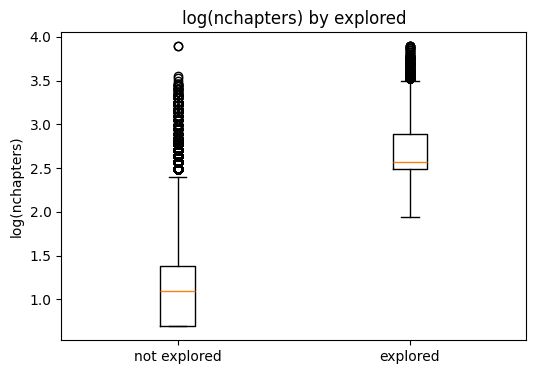

C:\Users\magic\AppData\Local\Temp\ipykernel_28192\82269097.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not explored", "explored"])


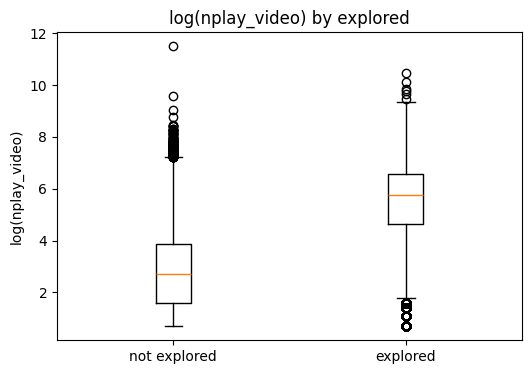

C:\Users\magic\AppData\Local\Temp\ipykernel_28192\82269097.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not explored", "explored"])


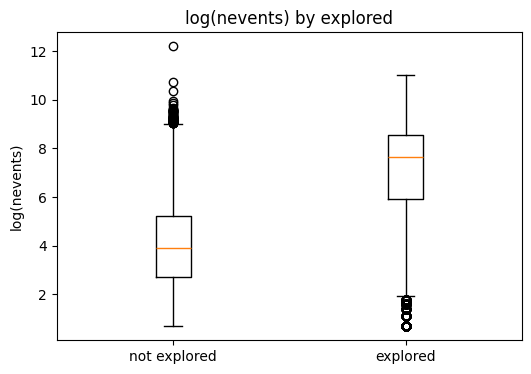

C:\Users\magic\AppData\Local\Temp\ipykernel_28192\82269097.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not explored", "explored"])


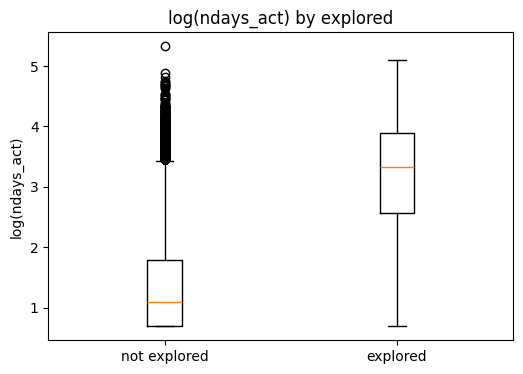

C:\Users\magic\AppData\Local\Temp\ipykernel_28192\82269097.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not explored", "explored"])


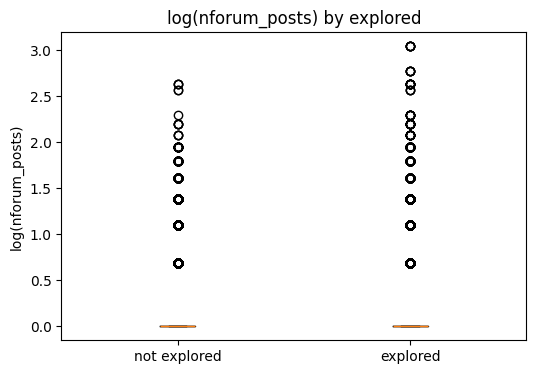

In [20]:
for col in behavior_cols:
    data0 = np.log1p(df_v[df_v["explored"] == 0][col].dropna())
    data1 = np.log1p(df_v[df_v["explored"] == 1][col].dropna())

    plt.figure(figsize=(6,4))
    plt.boxplot([data0, data1], labels=["not explored", "explored"])
    plt.title(f"log({col}) by explored")
    plt.ylabel(f"log({col})")
    plt.grid(False)
    plt.show()

In [21]:
# Cliff’s Delta 효과크기 함수
def cliffs_delta(x, y):
    nx = len(x)
    ny = len(y)

    greater = 0
    less = 0

    for xi in x:
        greater += np.sum(xi > y)
        less += np.sum(xi < y)

    delta = (greater - less) / (nx * ny)
    return delta

In [22]:


for col in behavior_cols:
    g0 = df_v[df_v["explored"] == 0][col].dropna()
    g1 = df_v[df_v["explored"] == 1][col].dropna()

    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
    delta = cliffs_delta(g1, g0)

    print(f"{col}")
    print(f"p-value: {p:.4e}")
    print(f"{col}: Cliff's delta = {delta:.4f}")
    print(f"median (0): {g0.median():.4f}")
    print(f"median (1): {g1.median():.4f}")
    print("-"*40)

nchapters
p-value: 0.0000e+00
nchapters: Cliff's delta = 0.9812
median (0): 2.0000
median (1): 12.0000
----------------------------------------
nplay_video
p-value: 0.0000e+00
nplay_video: Cliff's delta = 0.7557
median (0): 14.0000
median (1): 318.0000
----------------------------------------
nevents
p-value: 0.0000e+00
nevents: Cliff's delta = 0.7434
median (0): 49.0000
median (1): 2127.0000
----------------------------------------
ndays_act
p-value: 0.0000e+00
ndays_act: Cliff's delta = 0.8128
median (0): 2.0000
median (1): 27.0000
----------------------------------------
nforum_posts
p-value: 0.0000e+00
nforum_posts: Cliff's delta = 0.0575
median (0): 0.0000
median (1): 0.0000
----------------------------------------


### explored 단계 전환 요인 분석

Mann-Whitney U 검정 결과, explored 여부에 따라 주요 행동 변수들은 모두 통계적으로 유의한 차이를 보였다 (p < 0.001).

또한 효과크기(Cliff’s Delta)를 확인한 결과, nchapters(≈0.98), ndays_act(≈0.81), nplay_video(≈0.76), nevents(≈0.74) 등 대부분의 행동 변수에서 매우 큰 수준의 효과크기가 나타났다. 특히 nchapters의 경우 거의 완벽에 가까운 분리력을 보이며, explored 여부를 강하게 구분하는 변수로 확인되었다.

이는 explored 단계가 특정 단일 행동에 의해 발생한다기보다, 전반적인 학습 활동 수준이 일정 수준 이상 누적되었을 때 나타나는 결과적 지표임을 시사한다.

한편, nforum_posts의 경우 효과크기가 매우 낮고 중앙값 또한 차이가 없어, 포럼 활동은 explored 여부와 큰 관련이 없는 것으로 나타났다.

### Threshold 분석
어떠한 행동지표의 단계부터 explored가 되기 시작하냐?

전제: threshold 분석은 인과를 증명하는 분석이 아니라,
- explored와 행동 변`수 사이에 비선형적 전환 지점이 있는지 탐색하는 분석
- "행동이 explored를 유발했다”를 말하는 건 아니다

### 1. nchapters threshold 분석

In [51]:
# nchapters 기본 분포 확인
print(df["nchapters"].describe())

# explored별 중앙값도 다시 확인
print(
    df.groupby("explored")["nchapters"]
    .describe()[["count", "mean", "50%", "75%", "max"]]
)

count    475783.000000
mean          2.642255
std           4.349631
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          48.000000
Name: nchapters, dtype: float64
             count       mean   50%   75%   max
explored                                       
0         438199.0   1.629253   1.0   2.0  48.0
1          37584.0  14.453039  12.0  17.0  48.0


In [54]:
# nchapters 구간화
df["nchapters_bin"] = pd.cut(
    df["nchapters"],
    bins=[-1, 0, 1, 2, 5, 10, 20, np.inf],
    labels=["0", "1", "2", "3-5", "6-10", "11-20", "21+"]
)

# 구간별 explored rate
nchapters_threshold = (
    df.groupby("nchapters_bin", observed=False)["explored"]
    .agg(["count", "mean"])
    .reset_index()
)

nchapters_threshold["explored_rate(%)"] = nchapters_threshold["mean"] * 100
nchapters_threshold = nchapters_threshold.drop(columns="mean")

# 특정 구간이 rate는 높아도 표본이 너무 적으면 조심
nchapters_threshold["explored_rate(%)"] = nchapters_threshold["explored_rate(%)"].round(2)

print(
    nchapters_threshold.rename(columns={
        "nchapters_bin": "nchapters 구간",
        "count": "표본수",
        "explored_rate(%)": "explored 비율(%)"
    })
)

  nchapters 구간     표본수  explored 비율(%)
0            0  166598            0.00
1            1   77924            0.00
2            2   91723            0.00
3          3-5   82447            0.00
4         6-10   26262           35.56
5        11-20   26515           90.95
6          21+    4314           95.76


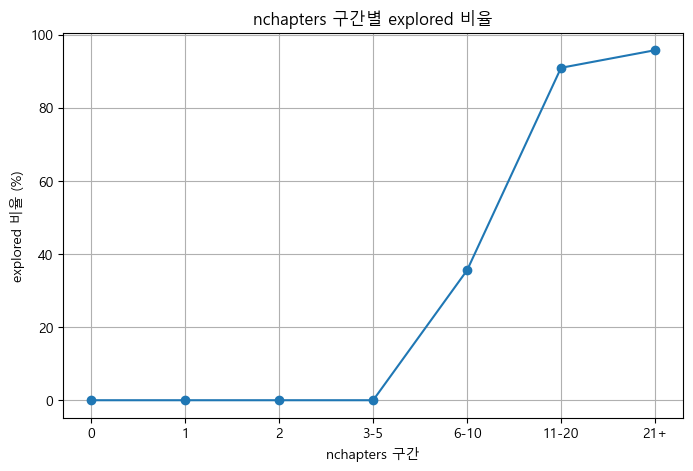

In [57]:
plot_df = nchapters_threshold.copy()

plt.figure(figsize=(8, 5))
plt.plot(plot_df["nchapters_bin"].astype(str), plot_df["explored_rate(%)"], marker="o")
plt.xlabel("nchapters 구간")
plt.ylabel("explored 비율 (%)")
plt.title("nchapters 구간별 explored 비율")
plt.grid(True)
plt.show()

In [62]:
roc_df = df[["explored", "nchapters"]].dropna()
y = roc_df["explored"]
x = roc_df["nchapters"]

fpr, tpr, thresholds = roc_curve(y, x)

# Youden's J statistic
j_scores = tpr - fpr
best_idx = j_scores.argmax()

best_threshold = thresholds[best_idx]

print(f"Best threshold (Youden J): {best_threshold}")

Best threshold (Youden J): 6.0


nchapters에 대한 threshold를 주관적으로 설정하는 대신,
explored 여부를 가장 잘 구분하는 기준값을 도출하기 위해
ROC 기반 분석을 수행하였다.

ROC 분석에서는 다양한 nchapters 기준값(threshold)에 대해
explored 여부를 얼마나 잘 구분할 수 있는지를 평가하며,
이때 Youden’s J (TPR - FPR)를 최대화하는 지점을
최적 threshold로 정의하였다.

그 결과, nchapters ≥ 6일 때 explored 여부를 가장 잘 구분하는 것으로 나타났다.

이는 nchapters가 일정 수준 이상에 도달할 경우,
explored 상태와 강하게 연관된 행동 패턴이 나타남을 시사하며,
explored가 단순한 활동 증가의 연속선상에 있는 것이 아니라
특정 참여 수준을 기준으로 구분되는 상태일 가능성을 보여준다.

In [65]:
# explored 분포 확인
class_counts = df["explored"].value_counts(dropna=False)
class_ratio = df["explored"].value_counts(normalize=True, dropna=False) * 100

print("[Class Count]")
print(class_counts)

print("\n[Class Ratio (%)]")
print(class_ratio)

[Class Count]
explored
0    496409
1     37584
Name: count, dtype: int64

[Class Ratio (%)]
explored
0    92.961705
1     7.038295
Name: proportion, dtype: float64


### 클래스 분포 확인

explored 변수의 클래스 분포를 확인하여,
데이터 내 클래스 불균형(class imbalance) 여부를 점검하였다.

이를 통해 특정 클래스가 과도하게 많은 경우,
ROC 해석 시 성능이 과대평가될 가능성이 있는지 확인하고자 한다.

In [64]:
roc_df = df.copy()
roc_df["nchapters"] = roc_df["nchapters"].fillna(0)
roc_df = roc_df[roc_df["explored"].notna()]

y = roc_df["explored"]
x = roc_df["nchapters"]

precision, recall, thresholds = precision_recall_curve(y, x)

# F1 score 계산
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print(f"Best threshold (F1): {best_threshold}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall: {recall[best_idx]:.4f}")

Best threshold (F1): 9.0
Precision: 0.8625
Recall: 0.8756


### ROC 분석의 한계 및 PR 기반 추가 검토

앞선 ROC 분석을 통해 nchapters를 기준으로 explored 여부를
가장 잘 구분하는 threshold를 도출할 수 있었다.
ROC는 다양한 threshold에 대해 전체적인 분류 성능을 평가하고,
TPR(True Positive Rate)과 FPR(False Positive Rate)의 균형을 기준으로
최적 기준값을 찾는 데 유용하다.

그러나 ROC 기반 평가는 다음과 같은 한계를 가진다.

- 클래스 간 비율 차이(불균형)가 존재할 경우 성능을 과대평가할 수 있음
- 실제 활용 관점에서 중요한 “예측의 정확도(precision)”를 직접적으로 반영하지 않음
- False Positive와 False Negative의 비용 차이를 충분히 반영하지 못함

특히 본 분석에서는 explored 사용자 식별이 중요한 상황이므로,
단순히 전체 구분 성능뿐 아니라
“explored로 예측한 사용자 중 실제 explored 비율(precision)” 또한 중요하게 고려할 필요가 있다.

이에 따라, ROC 분석의 한계를 보완하고 보다 실용적인 기준을 도출하기 위해
Precision-Recall(PR) 기반 분석을 추가로 수행하였다.

PR 분석에서는 precision과 recall 간의 trade-off를 고려하며,
두 지표의 조화 평균인 F1 score를 기준으로
최적 threshold를 도출하였다.

이를 통해 nchapters가 특정 수준 이상일 때
explored 사용자를 보다 정확하게 식별할 수 있는 기준을 확인하고자 한다.

In [66]:
# threshold별 성능 변화 그래프

# 결측 제거
plot_df = df[["explored", "nchapters"]].dropna().copy()

y = plot_df["explored"].astype(int).values
x = plot_df["nchapters"].values

# ROC 기반 값
fpr, tpr, roc_thresholds = roc_curve(y, x)
j_scores = tpr - fpr
best_idx_roc = np.argmax(j_scores)
best_threshold_roc = roc_thresholds[best_idx_roc]

# PR 기반 값
precision, recall, pr_thresholds = precision_recall_curve(y, x)

# precision_recall_curve는 thresholds 길이가 precision/recal보다 1 짧음
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx_pr = np.argmax(f1_scores)
best_threshold_pr = pr_thresholds[best_idx_pr]

print(f"Best ROC threshold (Youden J): {best_threshold_roc}")
print(f"Best PR threshold (F1): {best_threshold_pr}")

Best ROC threshold (Youden J): 6.0
Best PR threshold (F1): 9.0


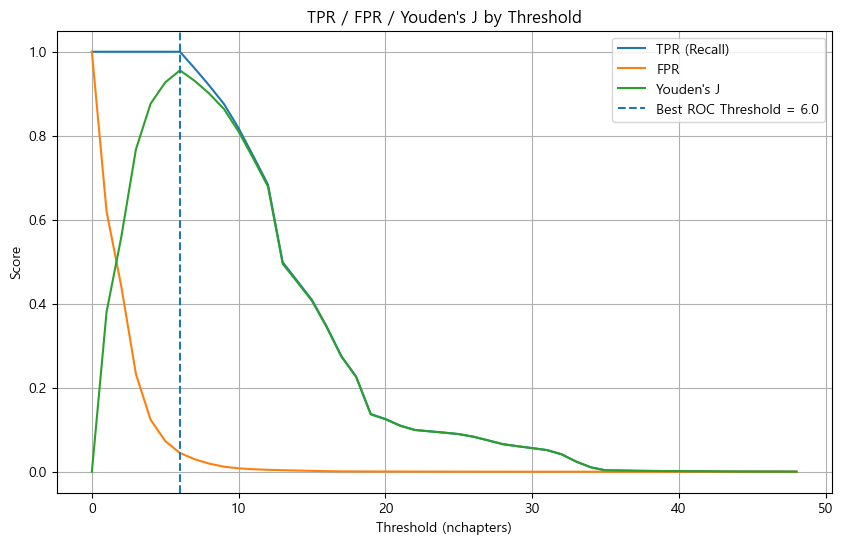

In [68]:
# ROC 기준으로 threshold가 바뀔 때
plt.figure(figsize=(10, 6))
plt.plot(roc_thresholds, tpr, label="TPR (Recall)")
plt.plot(roc_thresholds, fpr, label="FPR")
plt.plot(roc_thresholds, j_scores, label="Youden's J")

plt.axvline(best_threshold_roc, linestyle="--", label=f"Best ROC Threshold = {best_threshold_roc:.1f}")

plt.xlabel("Threshold (nchapters)")
plt.ylabel("Score")
plt.title("TPR / FPR / Youden's J by Threshold")
plt.legend()
plt.grid(True)
plt.show()

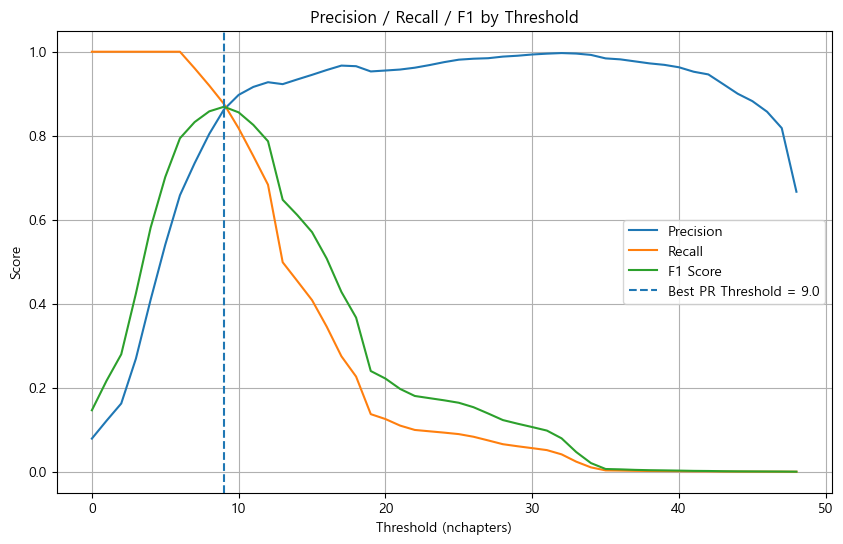

In [67]:
# PR 기준으로 threshold가 바뀔 때
plt.figure(figsize=(10, 6))
plt.plot(pr_thresholds, precision[:-1], label="Precision")
plt.plot(pr_thresholds, recall[:-1], label="Recall")
plt.plot(pr_thresholds, f1_scores, label="F1 Score")

plt.axvline(best_threshold_pr, linestyle="--", label=f"Best PR Threshold = {best_threshold_pr:.1f}")

plt.xlabel("Threshold (nchapters)")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 by Threshold")
plt.legend()
plt.grid(True)
plt.show()

## Threshold 기반 구조 발견

nchapters에 대해 ROC 및 PR 기반 threshold 분석을 수행한 결과,
explored 전환은 단일 기준이 아닌 다단계 구조를 가지는 것으로 나타났다.

- ROC 기반 threshold: nchapters ≥ 6  
  → explored 전환이 시작되는 경계 구간
(explored 많이 잡으려고 함, false positive 어느 정도 허용)

- PR 기반 threshold: nchapters ≥ 9  
  → 높은 신뢰도로 explored 사용자를 식별할 수 있는 구간

이를 통해 explored는 단순히 연속적인 증가가 아니라,
특정 참여 수준을 기준으로 구분되는 상태임을 확인할 수 있었다.

## Engagement 구조 해석

위 결과를 종합하면,
사용자의 학습 참여 수준은 다음과 같은 구조로 해석할 수 있다:

- nchapters < 6  
  → 낮은 참여 (disengaged)

- 6 ≤ nchapters < 9  
  → 전환 구간 (exploration transition zone)

- nchapters ≥ 9  
  → 높은 참여 (high engagement)

이는 explored가 단일 이벤트가 아니라,
행동 수준에 따라 점진적으로 확률이 증가하는 상태이며,
특정 구간에서 전환이 집중되는 패턴을 가진다는 것을 의미한다.

본 분석은 explored 전환이 임계점(threshold) 기반 구조를 가진다는 점을 보여주며,
이를 통해 다음과 같은 활용이 가능하다:

- 초기 단계에서 일정 수준 이상의 참여를 유도하는 전략 설계
- 사용자 참여 수준에 따른 세그먼트 정의 (low / mid / high engagement)
- explored 전환 가능성이 높은 사용자군 조기 식별

특히, nchapters ≥ 6 구간은 전환이 시작되는 핵심 구간으로,
이 구간 이전 사용자에 대한 개입 전략이 중요할 것으로 판단된다.

### ndays_act threshold 분석

In [69]:
# ndays_act 기본 분포 확인
print(df["ndays_act"].describe())

print(
    df.groupby("explored")["ndays_act"]
    .describe()[["count", "mean", "50%", "75%", "max"]]
)

count    532186.000000
mean          4.825112
std          11.151017
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max         205.000000
Name: ndays_act, dtype: float64
             count       mean   50%   75%    max
explored                                        
0         494602.0   2.709637   1.0   3.0  205.0
1          37584.0  32.664565  27.0  48.0  162.0


In [70]:
roc_df = df[["explored", "ndays_act"]].dropna()

y = roc_df["explored"]
x = roc_df["ndays_act"]

fpr, tpr, thresholds = roc_curve(y, x)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (Youden J): {best_threshold}")

Best threshold (Youden J): 7.0


In [71]:
pr_df = df[["explored", "ndays_act"]].dropna()

y = pr_df["explored"]
x = pr_df["ndays_act"]

precision, recall, thresholds = precision_recall_curve(y, x)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (F1): {best_threshold}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall: {recall[best_idx]:.4f}")

Best threshold (F1): 18.0
Precision: 0.7391
Recall: 0.6465


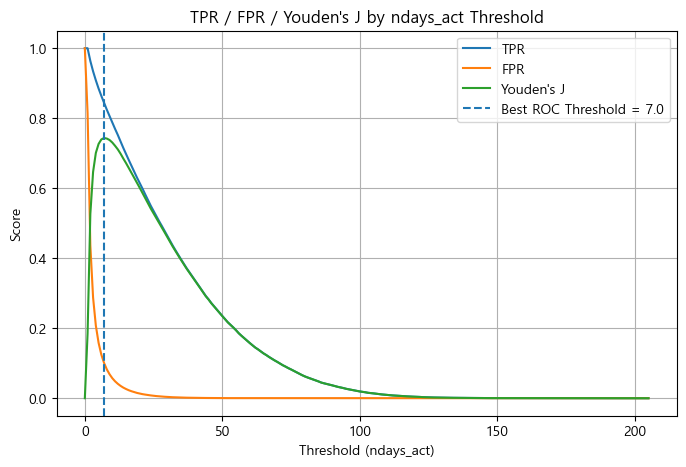

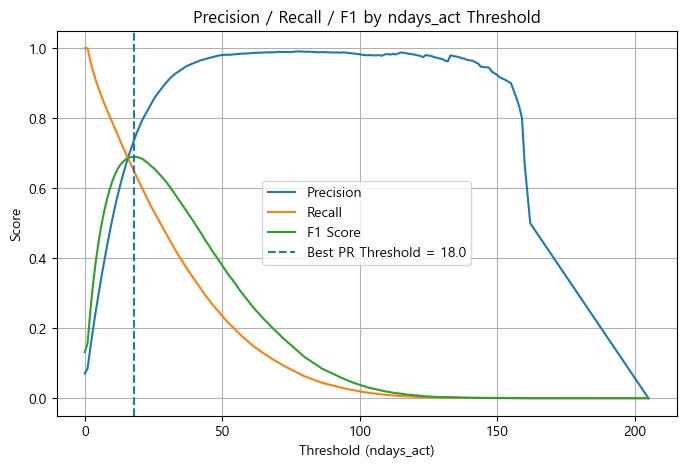

In [73]:
plot_df = df[["explored", "ndays_act"]].dropna().copy()
y = plot_df["explored"].astype(int).values
x = plot_df["ndays_act"].values

# ROC
fpr, tpr, roc_thresholds = roc_curve(y, x)
j_scores = tpr - fpr
best_idx_roc = np.argmax(j_scores)
best_threshold_roc = roc_thresholds[best_idx_roc]

# PR
precision, recall, pr_thresholds = precision_recall_curve(y, x)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx_pr = np.argmax(f1_scores)
best_threshold_pr = pr_thresholds[best_idx_pr]

# ROC 그래프
plt.figure(figsize=(8, 5))
plt.plot(roc_thresholds, tpr, label="TPR")
plt.plot(roc_thresholds, fpr, label="FPR")
plt.plot(roc_thresholds, j_scores, label="Youden's J")
plt.axvline(best_threshold_roc, linestyle="--", label=f"Best ROC Threshold = {best_threshold_roc:.1f}")
plt.xlabel("Threshold (ndays_act)")
plt.ylabel("Score")
plt.title("TPR / FPR / Youden's J by ndays_act Threshold")
plt.legend()
plt.grid(True)
plt.show()

# PR 그래프
plt.figure(figsize=(8, 5))
plt.plot(pr_thresholds, precision[:-1], label="Precision")
plt.plot(pr_thresholds, recall[:-1], label="Recall")
plt.plot(pr_thresholds, f1_scores, label="F1 Score")
plt.axvline(best_threshold_pr, linestyle="--", label=f"Best PR Threshold = {best_threshold_pr:.1f}")
plt.xlabel("Threshold (ndays_act)")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 by ndays_act Threshold")
plt.legend()
plt.grid(True)
plt.show()

### nevents threshold 분석

In [74]:
print(df["nevents"].describe())

print(
    df.groupby("explored")["nevents"]
    .describe()[["count", "mean", "50%", "75%", "max"]]
)

count    532186.000000
mean        357.682042
std        1390.863751
min           0.000000
25%           1.000000
50%          11.000000
75%         105.000000
max      197757.000000
Name: nevents, dtype: float64
             count         mean     50%     75%       max
explored                                                 
0         494602.0   128.564636     8.0    70.0  197757.0
1          37584.0  3372.846131  2127.0  5207.0   61376.0


In [75]:
roc_df = df[["explored", "nevents"]].dropna()

y = roc_df["explored"]
x = roc_df["nevents"]

fpr, tpr, thresholds = roc_curve(y, x)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (Youden J): {best_threshold}")

Best threshold (Youden J): 187.0


In [76]:
pr_df = df[["explored", "nevents"]].dropna()

y = pr_df["explored"]
x = pr_df["nevents"]

precision, recall, thresholds = precision_recall_curve(y, x)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (F1): {best_threshold}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall: {recall[best_idx]:.4f}")

Best threshold (F1): 1274.0
Precision: 0.6857
Recall: 0.6107


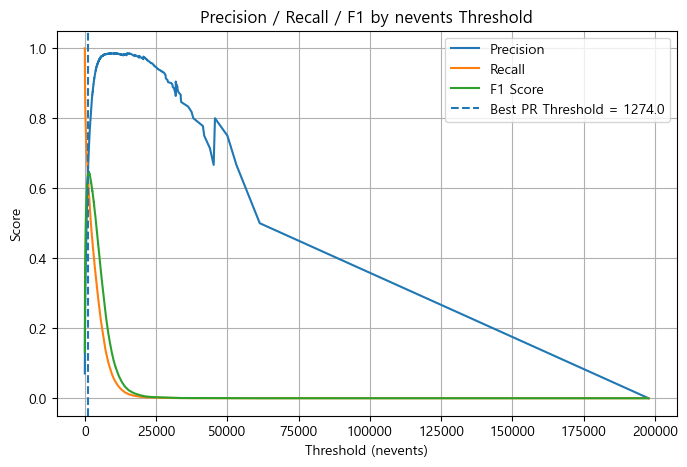

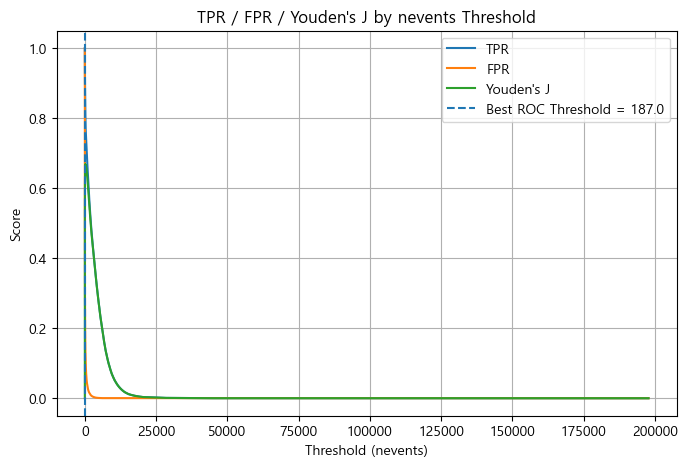

In [77]:
plot_df = df[["explored", "nevents"]].dropna().copy()
y = plot_df["explored"].astype(int).values
x = plot_df["nevents"].values

fpr, tpr, roc_thresholds = roc_curve(y, x)
j_scores = tpr - fpr
best_idx_roc = np.argmax(j_scores)
best_threshold_roc = roc_thresholds[best_idx_roc]

precision, recall, pr_thresholds = precision_recall_curve(y, x)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx_pr = np.argmax(f1_scores)
best_threshold_pr = pr_thresholds[best_idx_pr]

plt.figure(figsize=(8, 5))
plt.plot(pr_thresholds, precision[:-1], label="Precision")
plt.plot(pr_thresholds, recall[:-1], label="Recall")
plt.plot(pr_thresholds, f1_scores, label="F1 Score")
plt.axvline(best_threshold_pr, linestyle="--", label=f"Best PR Threshold = {best_threshold_pr:.1f}")
plt.xlabel("Threshold (nevents)")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 by nevents Threshold")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(roc_thresholds, tpr, label="TPR")
plt.plot(roc_thresholds, fpr, label="FPR")
plt.plot(roc_thresholds, j_scores, label="Youden's J")
plt.axvline(best_threshold_roc, linestyle="--", label=f"Best ROC Threshold = {best_threshold_roc:.1f}")
plt.xlabel("Threshold (nevents)")
plt.ylabel("Score")
plt.title("TPR / FPR / Youden's J by nevents Threshold")
plt.legend()
plt.grid(True)
plt.show()

### nplay_video Threshold 분석

In [78]:
print(df["nplay_video"].describe())

print(
    df.groupby("explored")["nplay_video"]
    .describe()[["count", "mean", "50%", "75%", "max"]]
)

count    348922.000000
mean         60.313540
std         314.961586
min           0.000000
25%           0.000000
50%           1.000000
75%          20.000000
max       98517.000000
Name: nplay_video, dtype: float64
             count        mean    50%    75%      max
explored                                             
0         325147.0   24.471350    0.0   13.0  98517.0
1          23775.0  550.491483  318.0  701.0  34596.0


In [79]:
roc_df = df[["explored", "nplay_video"]].dropna()

y = roc_df["explored"]
x = roc_df["nplay_video"]

fpr, tpr, thresholds = roc_curve(y, x)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (Youden J): {best_threshold}")

Best threshold (Youden J): 39.0


In [80]:
pr_df = df[["explored", "nplay_video"]].dropna()

y = pr_df["explored"]
x = pr_df["nplay_video"]

precision, recall, thresholds = precision_recall_curve(y, x)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (F1): {best_threshold}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall: {recall[best_idx]:.4f}")

Best threshold (F1): 199.0
Precision: 0.6358
Recall: 0.6325


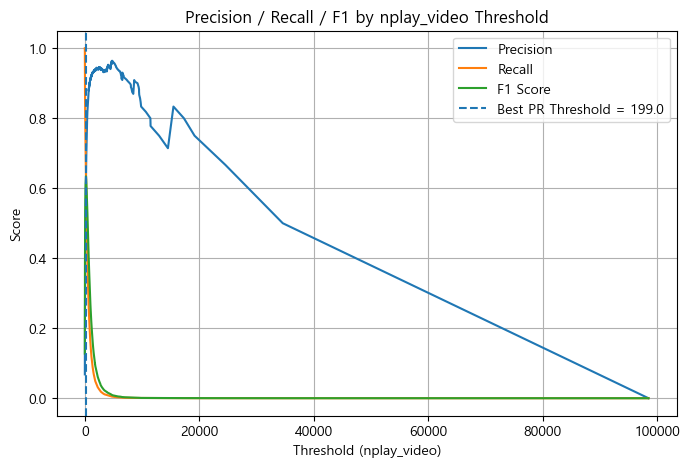

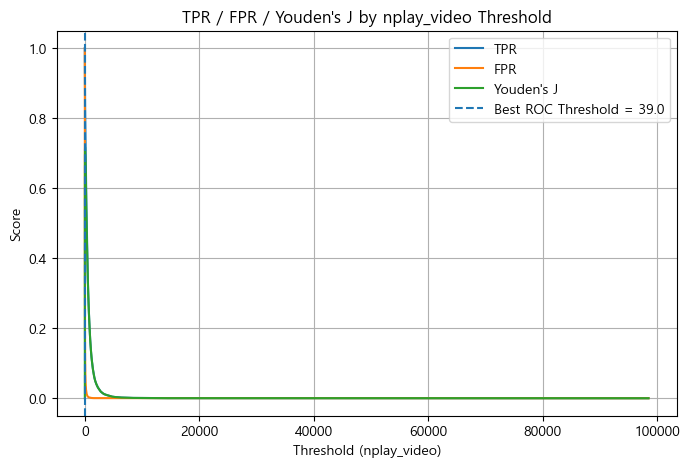

In [81]:
plot_df = df[["explored", "nplay_video"]].dropna().copy()
y = plot_df["explored"].astype(int).values
x = plot_df["nplay_video"].values

fpr, tpr, roc_thresholds = roc_curve(y, x)
j_scores = tpr - fpr
best_idx_roc = np.argmax(j_scores)
best_threshold_roc = roc_thresholds[best_idx_roc]

precision, recall, pr_thresholds = precision_recall_curve(y, x)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx_pr = np.argmax(f1_scores)
best_threshold_pr = pr_thresholds[best_idx_pr]

plt.figure(figsize=(8, 5))
plt.plot(pr_thresholds, precision[:-1], label="Precision")
plt.plot(pr_thresholds, recall[:-1], label="Recall")
plt.plot(pr_thresholds, f1_scores, label="F1 Score")
plt.axvline(best_threshold_pr, linestyle="--", label=f"Best PR Threshold = {best_threshold_pr:.1f}")
plt.xlabel("Threshold (nplay_video)")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 by nplay_video Threshold")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(roc_thresholds, tpr, label="TPR")
plt.plot(roc_thresholds, fpr, label="FPR")
plt.plot(roc_thresholds, j_scores, label="Youden's J")
plt.axvline(best_threshold_roc, linestyle="--", label=f"Best ROC Threshold = {best_threshold_roc:.1f}")
plt.xlabel("Threshold (nplay_video)")
plt.ylabel("Score")
plt.title("TPR / FPR / Youden's J by nplay_video Threshold")
plt.legend()
plt.grid(True)
plt.show()

### nforum_posts threshold 분석
효과크기가 매우적었기에 진행하지 않음.

In [92]:
def cap_upper(series, q=0.99):
    upper = series.quantile(q)
    return series.clip(upper=upper)

def threshold_summary(y, x):
    # ROC
    fpr, tpr, roc_thresholds = roc_curve(y, x)
    j_scores = tpr - fpr
    best_idx_roc = np.argmax(j_scores)
    best_threshold_roc = roc_thresholds[best_idx_roc]

    # PR
    precision, recall, pr_thresholds = precision_recall_curve(y, x)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    best_idx_pr = np.argmax(f1_scores)
    best_threshold_pr = pr_thresholds[best_idx_pr]

    return {
        "roc_threshold": best_threshold_roc,
        "roc_j": j_scores[best_idx_roc],
        "pr_threshold": best_threshold_pr,
        "precision": precision[best_idx_pr],
        "recall": recall[best_idx_pr],
        "f1": f1_scores[best_idx_pr]
    }

def compare_versions(df, target_col, feature_col, cap_q=0.99):
    temp = df[[target_col, feature_col]].dropna().copy()
    temp["raw"] = temp[feature_col]
    temp["log1p"] = np.log1p(temp[feature_col])
    temp["capped"] = cap_upper(temp[feature_col], q=cap_q)

    y = temp[target_col].astype(int)

    rows = []
    for version in ["raw", "log1p", "capped"]:
        result = threshold_summary(y, temp[version])

        if version == "log1p":
            roc_thr = np.expm1(result["roc_threshold"])
            pr_thr = np.expm1(result["pr_threshold"])
        else:
            roc_thr = result["roc_threshold"]
            pr_thr = result["pr_threshold"]

        rows.append({
            "version": version,
            "roc_threshold": roc_thr,
            "roc_j": result["roc_j"],
            "pr_threshold": pr_thr,
            "precision": result["precision"],
            "recall": result["recall"],
            "f1": result["f1"]
        })

    return temp, pd.DataFrame(rows)

def plot_distributions(temp, original_col, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(temp["raw"], bins=50)
    axes[0].set_title(f"{title_prefix} Raw")

    axes[1].hist(temp["log1p"], bins=50)
    axes[1].set_title(f"{title_prefix} log1p")

    axes[2].hist(temp["capped"], bins=50)
    axes[2].set_title(f"{title_prefix} capped")

    for ax in axes:
        ax.set_ylabel("Frequency")
        ax.grid(False)

    plt.tight_layout()
    plt.show()

def plot_threshold_curves(temp, target_col, feature_version, title_prefix=""):
    y = temp[target_col].astype(int).values
    x = temp[feature_version].values

    # ROC
    fpr, tpr, roc_thresholds = roc_curve(y, x)
    j_scores = tpr - fpr
    best_idx_roc = np.argmax(j_scores)
    best_threshold_roc = roc_thresholds[best_idx_roc]

    # PR
    precision, recall, pr_thresholds = precision_recall_curve(y, x)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    best_idx_pr = np.argmax(f1_scores)
    best_threshold_pr = pr_thresholds[best_idx_pr]

    plt.figure(figsize=(8, 5))
    plt.plot(pr_thresholds, precision[:-1], label="Precision")
    plt.plot(pr_thresholds, recall[:-1], label="Recall")
    plt.plot(pr_thresholds, f1_scores, label="F1 Score")
    plt.axvline(best_threshold_pr, linestyle="--", label=f"Best PR Threshold = {best_threshold_pr:.3f}")
    plt.xlabel(f"Threshold ({feature_version})")
    plt.ylabel("Score")
    plt.title(f"{title_prefix} PR-based Threshold Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(roc_thresholds, tpr, label="TPR")
    plt.plot(roc_thresholds, fpr, label="FPR")
    plt.plot(roc_thresholds, j_scores, label="Youden's J")
    plt.axvline(best_threshold_roc, linestyle="--", label=f"Best ROC Threshold = {best_threshold_roc:.3f}")
    plt.xlabel(f"Threshold ({feature_version})")
    plt.ylabel("Score")
    plt.title(f"{title_prefix} ROC-based Threshold Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

### nplay_video의 왜곡 분포 및 보정 분석

nplay_video는 분포의 비대칭성과 상위 극단값이 큰 변수로 확인되었다.
이러한 경우 원본 값을 그대로 사용한 threshold 분석은
소수의 극단값에 의해 기준값이 왜곡될 가능성이 있다.

이를 보완하기 위해 다음 두 가지 보정 방식을 적용하였다.

- log1p 변환: 큰 값을 압축하여 분포 왜곡 완화
- 상위 99% 절단(capping): 극단값의 영향 완화

이후 원본(raw), log 변환값, capped 값을 각각 사용하여
ROC 및 PR 기반 threshold를 다시 산출하고,
결과의 안정성을 비교하였다.

이를 통해 도출된 threshold가 특정 극단값에 의해 형성된 값인지,
아니면 전체적인 행동 구조를 반영하는 기준인지 점검하고자 하였다.

count    348922.000000
mean         60.313540
std         314.961586
min           0.000000
50%           1.000000
75%          20.000000
90%         113.000000
95%         288.000000
99%        1073.000000
max       98517.000000
Name: nplay_video, dtype: float64


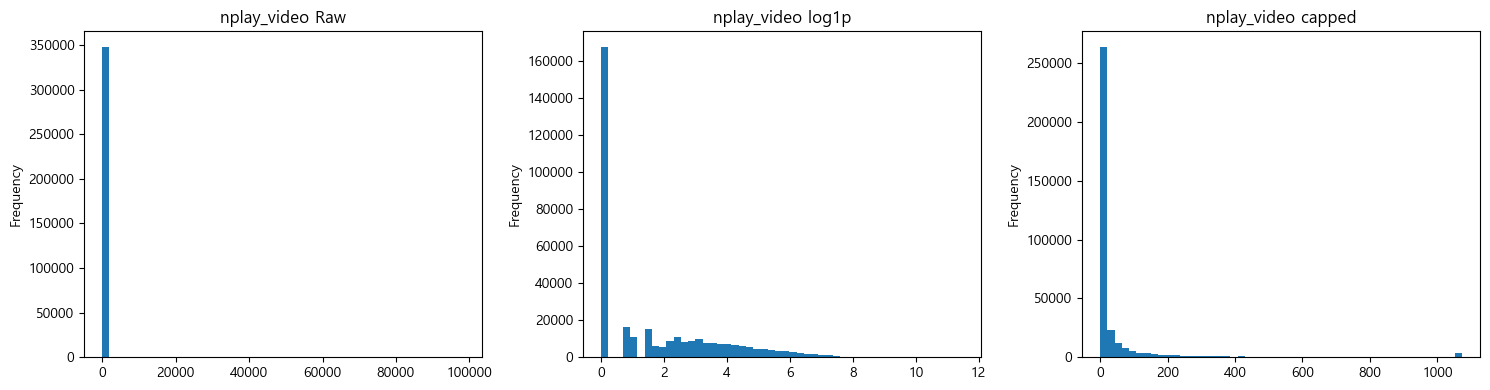

,version,roc_threshold,roc_j,pr_threshold,precision,recall,f1
0,raw,39.0,0.716847,199.0,0.635802,0.632513,0.634154
1,log1p,39.0,0.716847,199.0,0.635802,0.632513,0.634154
2,capped,39.0,0.716847,199.0,0.635802,0.632513,0.634154


In [93]:
print(df["nplay_video"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

temp_video, result_video = compare_versions(
    df=df,
    target_col="explored",
    feature_col="nplay_video",
    cap_q=0.99
)

plot_distributions(temp_video, "nplay_video", title_prefix="nplay_video")
display(result_video)

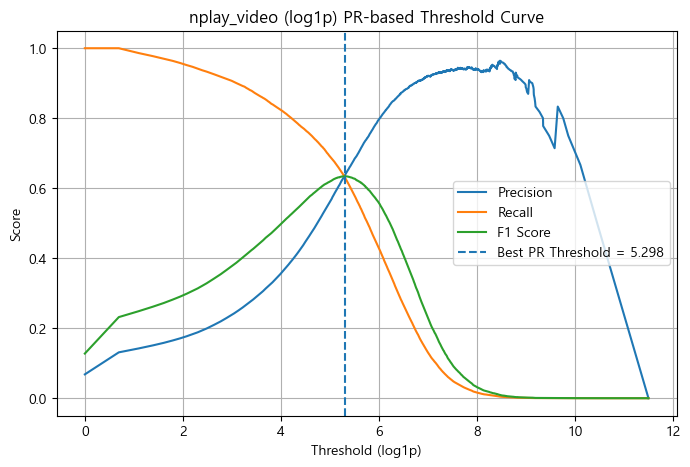

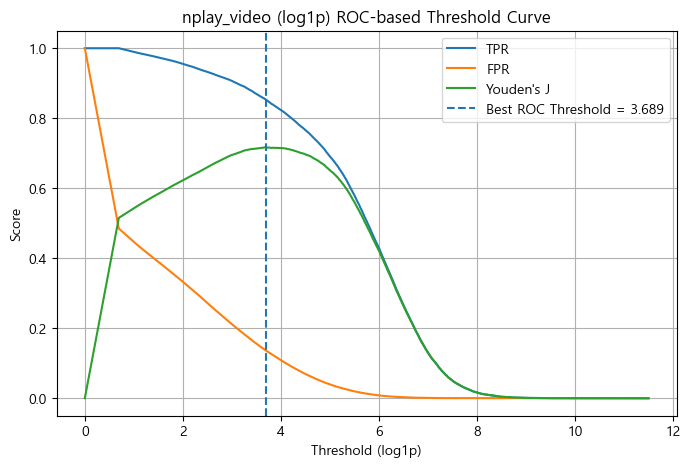

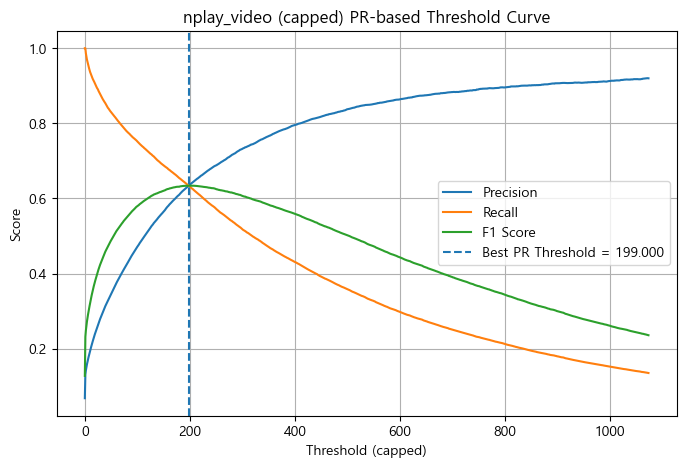

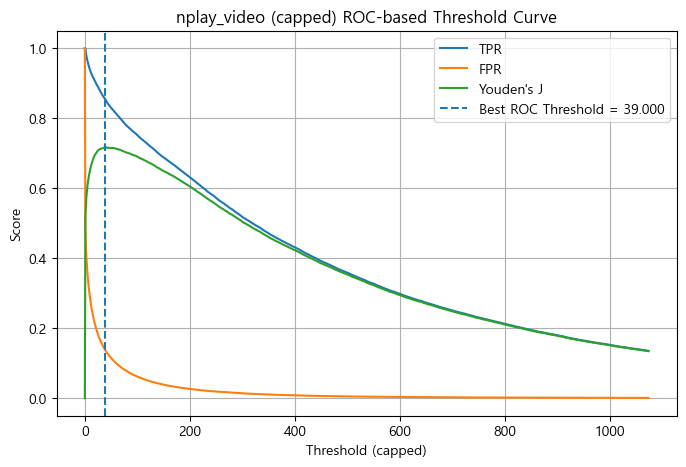

In [94]:
plot_threshold_curves(temp_video, "explored", "log1p", title_prefix="nplay_video (log1p)")
plot_threshold_curves(temp_video, "explored", "capped", title_prefix="nplay_video (capped)")

### nevents의 왜곡 분포 및 보정 분석

nevents 역시 매우 큰 범위와 극단값을 포함하는 heavy-tailed 분포를 보였으며,
원본 기준 threshold는 일부 큰 값에 민감하게 반응할 가능성이 있다.

따라서 nplay_video와 동일하게
log1p 변환과 상위 99% 절단(capping)을 적용하여
threshold를 다시 산출하였다.

이 비교를 통해 nevents의 threshold가
원본 데이터의 왜곡에 의해 결정되는지,
혹은 보정 이후에도 유사하게 유지되는 안정적인 구조인지 확인하고자 하였다.

count    532186.000000
mean        357.682042
std        1390.863751
min           0.000000
50%          11.000000
75%         105.000000
90%         610.000000
95%        1750.000000
99%        7228.150000
max      197757.000000
Name: nevents, dtype: float64


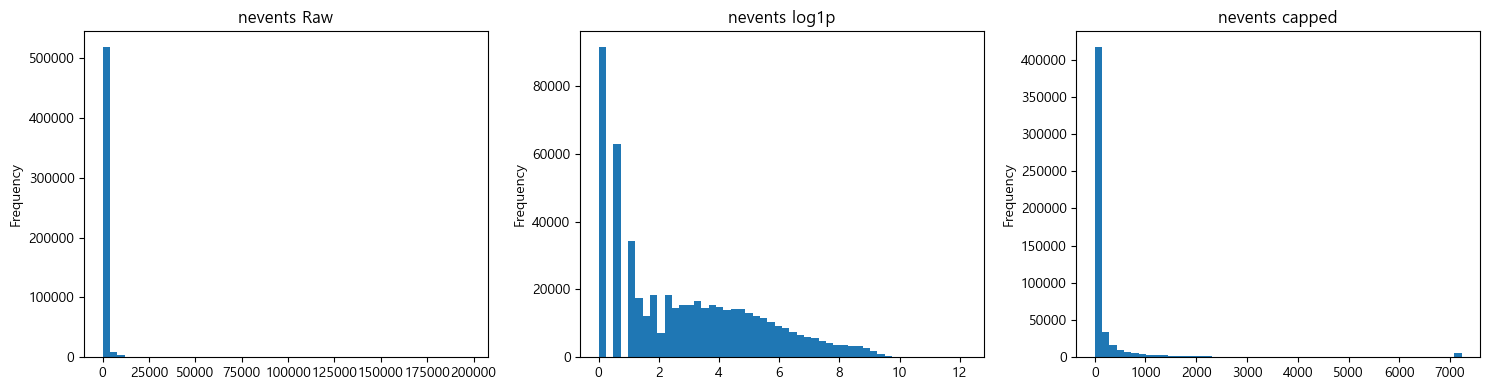

,version,roc_threshold,roc_j,pr_threshold,precision,recall,f1
0,raw,187.0,0.668171,1274.0,0.685717,0.610712,0.646045
1,log1p,187.0,0.668171,1274.0,0.685717,0.610712,0.646045
2,capped,187.0,0.668171,1274.0,0.685717,0.610712,0.646045


In [95]:
print(df["nevents"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

temp_events, result_events = compare_versions(
    df=df,
    target_col="explored",
    feature_col="nevents",
    cap_q=0.99
)

plot_distributions(temp_events, "nevents", title_prefix="nevents")
display(result_events)

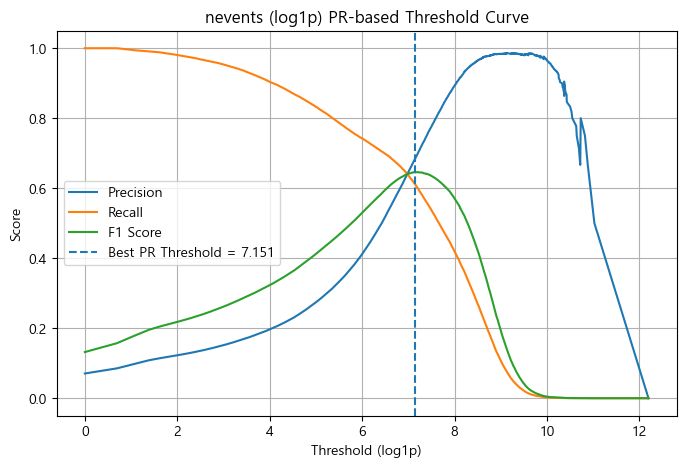

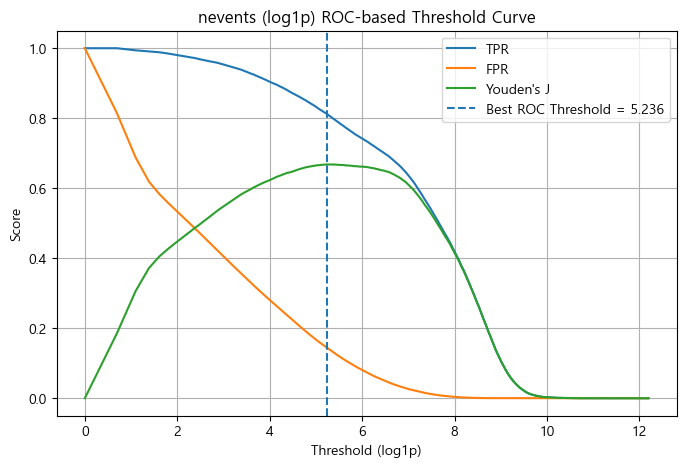

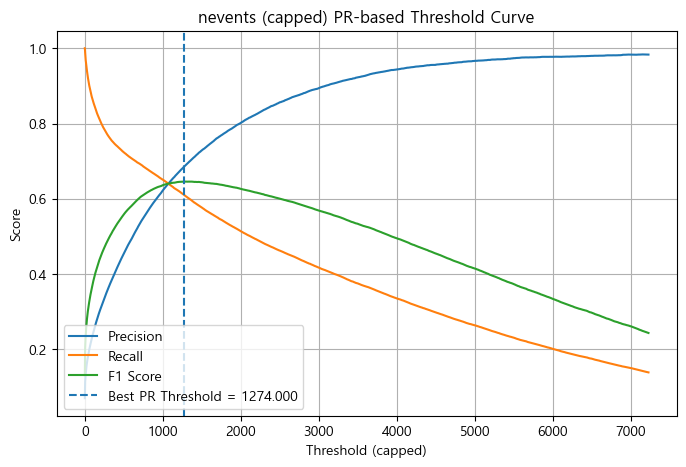

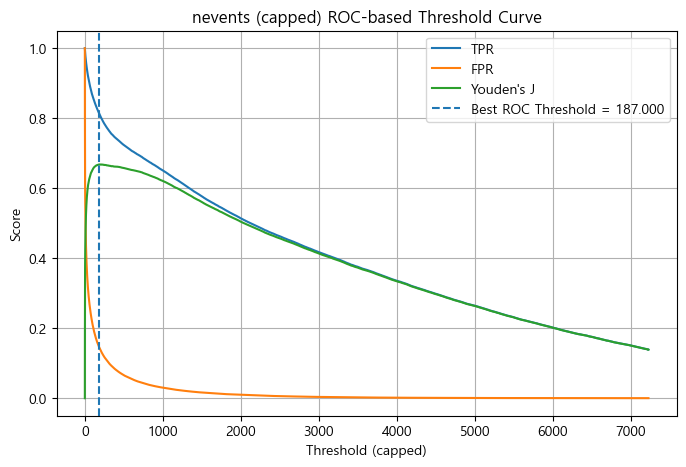

In [97]:
plot_threshold_curves(temp_events, "explored", "log1p", title_prefix="nevents (log1p)")
plot_threshold_curves(temp_events, "explored", "capped", title_prefix="nevents (capped)")

### ndays_act의 왜곡 분포 및 보정 분석

ndays_act는 nplay_video나 nevents에 비해 상대적으로 해석 가능성이 높은 변수이지만,
분포의 비대칭성과 상위 구간의 영향 가능성을 함께 점검할 필요가 있다.

이에 따라 raw, log1p, capped 세 가지 버전에 대해
ROC 및 PR 기반 threshold를 비교하였다.

이를 통해 ndays_act의 threshold가
분포 왜곡에 민감한 결과인지,
아니면 다양한 보정 방식에서도 일관되게 나타나는 안정적인 기준인지 확인하고자 하였다.

count    532186.000000
mean          4.825112
std          11.151017
min           0.000000
50%           1.000000
75%           4.000000
90%          10.000000
95%          22.000000
99%          62.000000
max         205.000000
Name: ndays_act, dtype: float64


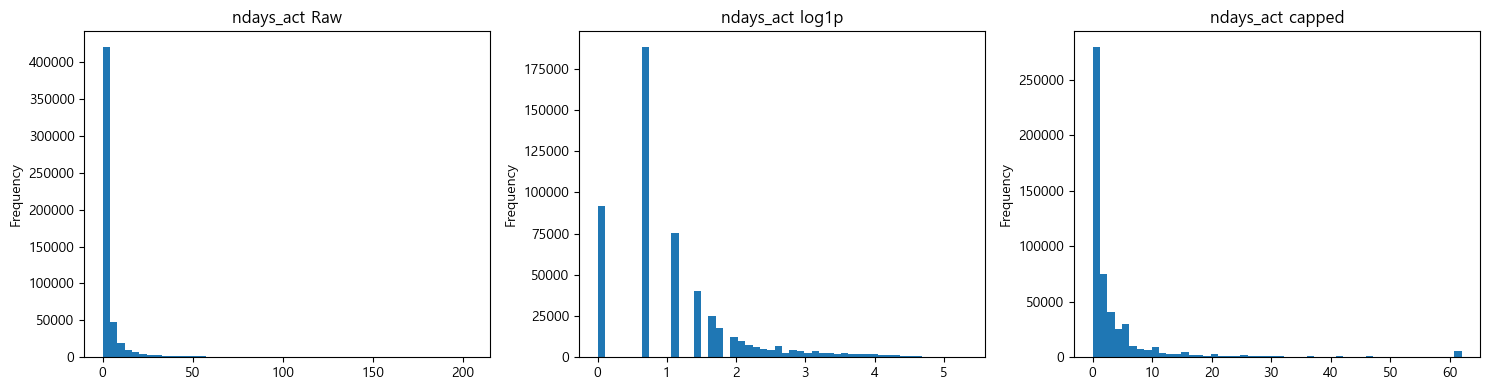

,version,roc_threshold,roc_j,pr_threshold,precision,recall,f1
0,raw,7.0,0.743528,18.0,0.739148,0.646499,0.689726
1,log1p,7.0,0.743528,18.0,0.739148,0.646499,0.689726
2,capped,7.0,0.743528,18.0,0.739148,0.646499,0.689726


In [98]:
print(df["ndays_act"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

temp_days, result_days = compare_versions(
    df=df,
    target_col="explored",
    feature_col="ndays_act",
    cap_q=0.99
)

plot_distributions(temp_days, "ndays_act", title_prefix="ndays_act")
display(result_days)

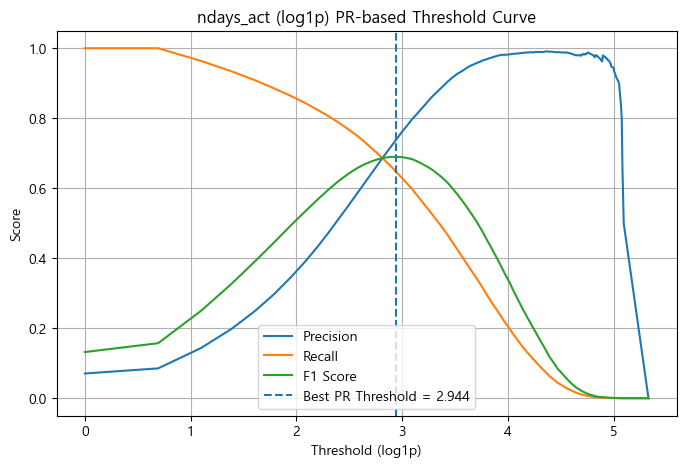

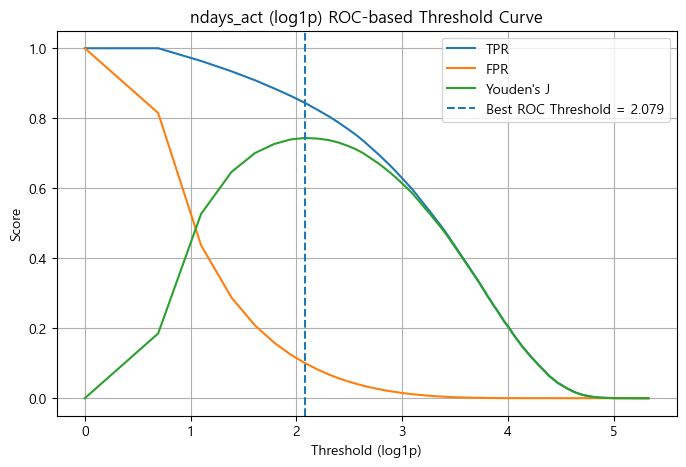

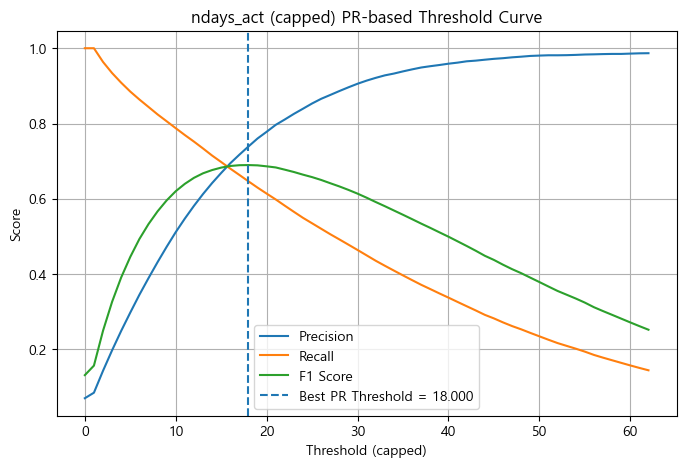

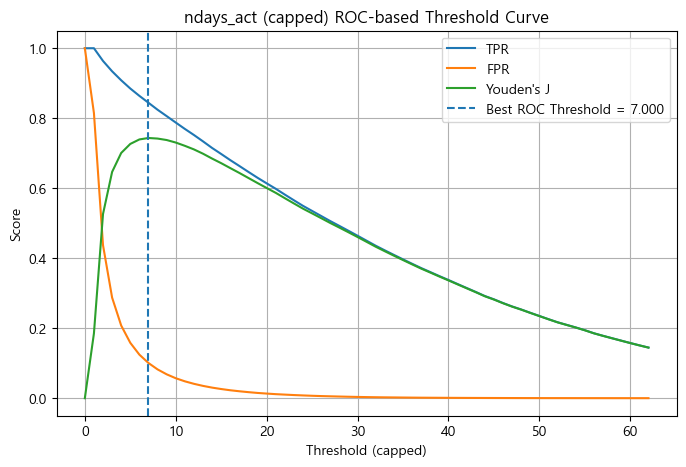

In [99]:
plot_threshold_curves(temp_days, "explored", "log1p", title_prefix="ndays_act (log1p)")
plot_threshold_curves(temp_days, "explored", "capped", title_prefix="ndays_act (capped)")

극단값의 영향을 점검하기 위해 log 변환 및 상위 구간 절단(capping)을 적용한 결과,
세 가지 방식에서 동일한 threshold가 도출되었다.

이는 threshold가 극단값 영역이 아닌 비교적 일반적인 값 구간에서 형성되었음을 의미하며,
해당 행동 지표가 안정적인 전환 기준으로 작용하고 있음을 시사한다.

In [107]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def threshold_test(df, feature, threshold, target="explored"):
    temp = df[[feature, target]].dropna().copy()

    # threshold 기준 그룹 생성
    temp["group"] = (temp[feature] >= threshold).astype(int)

    # contingency table
    ct = pd.crosstab(temp["group"], temp[target])

    # chi-square
    chi2, p, dof, expected = chi2_contingency(ct)

    # effect size
    v = cramers_v(ct)

    # 전환율 계산
    rates = ct.div(ct.sum(axis=1), axis=0)

    result = {
        "feature": feature,
        "threshold": threshold,
        "chi2": chi2,
        "p_value": p,
        "cramers_v": v,
        "low_group_rate": rates.loc[0, 1] if 1 in rates.columns else 0,
        "high_group_rate": rates.loc[1, 1] if 1 in rates.columns else 0,
        "gap": (rates.loc[1, 1] - rates.loc[0, 1]) if 1 in rates.columns else 0
    }

    return ct, pd.DataFrame([result])

In [110]:
# nchapters ROC기반 threshold
ct_chap, res_chap = threshold_test(df, "nchapters", 6)
display(ct_chap)
display(res_chap)

explored,0,1
group,,
0,418692,0
1,19507,37584


,feature,threshold,chi2,p_value,cramers_v,low_group_rate,high_group_rate,gap
0,nchapters,6,299263.960654,0.0,0.793091,0.0,0.658317,0.658317


In [111]:
# nchapters PR기반 threshold
ct_chap, res_chap = threshold_test(df, "nchapters", 9)
display(ct_chap)
display(res_chap)

explored,0,1
group,,
0,432955,4677
1,5244,32907


,feature,threshold,chi2,p_value,cramers_v,low_group_rate,high_group_rate,gap
0,nchapters,9,350002.04244,0.0,0.857691,0.010687,0.862546,0.851859


In [115]:
# nplay_video ROC기반 threshold
ct_video, res_video = threshold_test(df, "nplay_video", 39)
display(ct_video)
display(res_video)

explored,0,1
group,,
0,280673,3480
1,44474,20295


,feature,threshold,chi2,p_value,cramers_v,low_group_rate,high_group_rate,gap
0,nplay_video,39,75306.809131,0.0,0.464572,0.012247,0.313344,0.301097


In [116]:
# nplay_video PR기반 threshold
ct_video, res_video = threshold_test(df, "nplay_video", 199)
display(ct_video)
display(res_video)

explored,0,1
group,,
0,316533,8737
1,8614,15038


,feature,threshold,chi2,p_value,cramers_v,low_group_rate,high_group_rate,gap
0,nplay_video,199,128753.50201,0.0,0.607457,0.026861,0.635802,0.608942


In [117]:
# nevents ROC기반 threshold
ct_events, res_events = threshold_test(df, "nevents", 187)
display(ct_events)
display(res_events)

explored,0,1
group,,
0,423256,7050
1,71346,30534


,feature,threshold,chi2,p_value,cramers_v,low_group_rate,high_group_rate,gap
0,nevents,187,100742.432702,0.0,0.435085,0.016384,0.299706,0.283322


In [118]:
# nevents PR기반 threshold
ct_events, res_events = threshold_test(df, "nevents", 1274)
display(ct_events)
display(res_events)

explored,0,1
group,,
0,484082,14631
1,10520,22953


,feature,threshold,chi2,p_value,cramers_v,low_group_rate,high_group_rate,gap
0,nevents,1274,205891.58913,0.0,0.621996,0.029338,0.685717,0.656379


In [121]:
# ndays_act ROC기반 threshold
ct_days, res_days = threshold_test(df, "ndays_act", 7)
display(ct_days)
display(res_days)

explored,0,1
group,,
0,444841,5858
1,49761,31726


,feature,threshold,chi2,p_value,cramers_v,low_group_rate,high_group_rate,gap
0,ndays_act,7,148910.354891,0.0,0.52897,0.012998,0.389338,0.376341


In [ ]:
# ndays_act PR기반 threshold
ct_days, res_days = threshold_test(df, "ndays_act", 18)
display(ct_days)
display(res_days)

explored,0,1
group,,
0,486027,13286
1,8575,24298


,feature,threshold,chi2,p_value,cramers_v,low_group_rate,high_group_rate,gap
0,ndays_act,18,238569.210057,0.0,0.669538,0.026609,0.739148,0.712539


In [23]:
df_v.groupby("age_group")["explored"].mean().sort_values()

age_group
under_20    0.106662
20s         0.107230
50s         0.110815
40s         0.113732
30s         0.120369
60_plus     0.132636
unknown     0.140652
Name: explored, dtype: float64

In [24]:
df_v.groupby("LoE_DI")["explored"].mean().sort_values()

LoE_DI
Secondary              0.102427
Bachelor's             0.102854
Less than Secondary    0.113510
Doctorate              0.129717
Master's               0.133697
unknown                0.136912
Name: explored, dtype: float64

In [25]:
df_v.groupby("LoE_DI")["explored"].mean().sort_values()

LoE_DI
Secondary              0.102427
Bachelor's             0.102854
Less than Secondary    0.113510
Doctorate              0.129717
Master's               0.133697
unknown                0.136912
Name: explored, dtype: float64

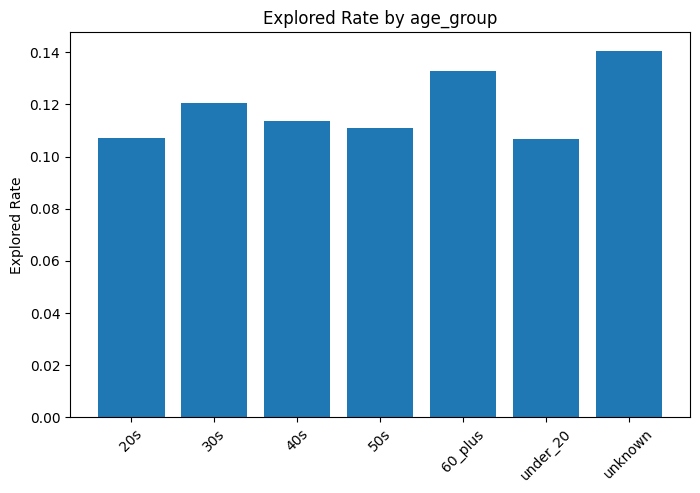

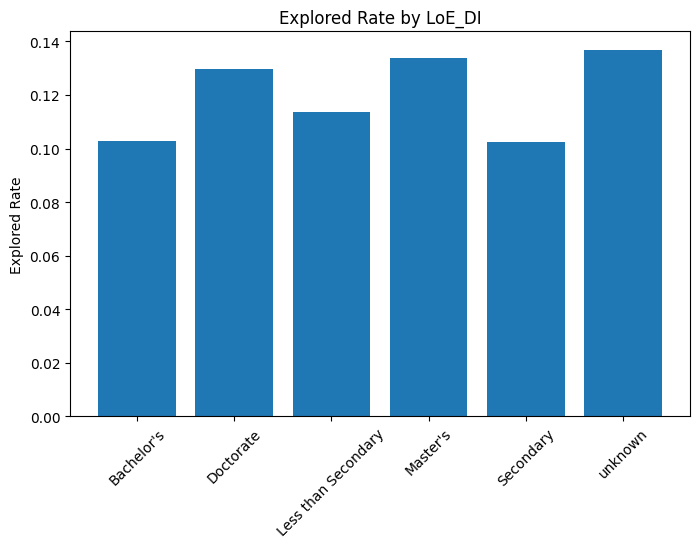

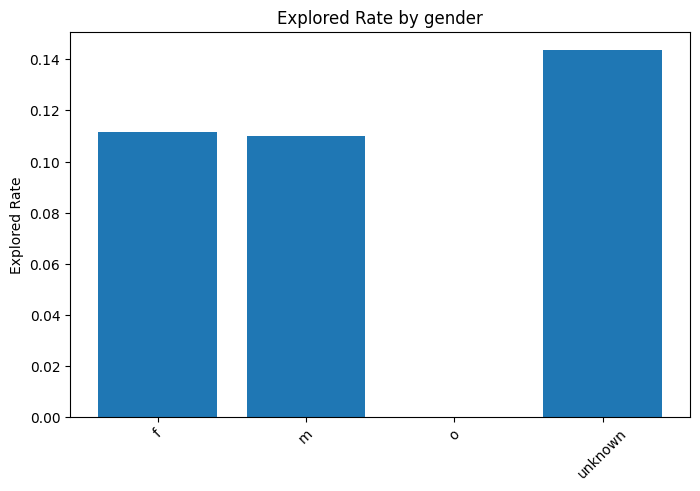

In [26]:
def plot_rate(col):
    temp = df_v.groupby(col)["explored"].mean()

    plt.figure(figsize=(8,5))
    plt.bar(temp.index.astype(str), temp.values)
    plt.title(f"Explored Rate by {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Explored Rate")
    plt.grid(False)
    plt.show()

plot_rate("age_group")
plot_rate("LoE_DI")
plot_rate("gender")

In [27]:
def chi_test(col):
    table = pd.crosstab(df_v[col], df_v["explored"])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col} p-value: {p:.4e}")

def cramers_v(table):
    chi2, _, _, _ = chi2_contingency(table)
    n = table.values.sum()
    return np.sqrt(chi2 / (n * (min(table.shape)-1)))

for col in ["age_group", "LoE_DI", "gender"]:
    table = pd.crosstab(df_v[col], df_v["explored"])
    chi_test(col)
    print(f"효과크기 {col}, {cramers_v(table)}")

age_group p-value: 2.7146e-105
효과크기 age_group, 0.039290710913643216
LoE_DI p-value: 4.1481e-167
효과크기 LoE_DI, 0.049074484428983156
gender p-value: 2.5443e-100
효과크기 gender, 0.03777778904422365


demographic 변수들은 explored 여부와 통계적으로 유의한 관계를 가지지만, 그 효과크기는 매우 작아 실질적인 설명력은 거의 없는 것으로 나타났다.